In [1]:
from cayman_office_system import *

INFO:shining_pebbles:Shining Pebbles package initialized
INFO:numexpr.utils:Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.
/Users/juneyoungpark/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
trades = Trades()

| import trade of (date, index) = (2024-09-02, None)
|- cash flow of trade: -614581438.0
| import trade of (date, index) = (2024-09-05, None)
|- cash flow of trade: -529470241.0
| import trade of (date, index) = (2024-09-06, None)
|- cash flow of trade: -91060069.0
| import trade of (date, index) = (2024-09-09, None)
|- cash flow of trade: -384482599.0
| import trade of (date, index) = (2024-09-10, None)
|- cash flow of trade: -625076151.0
| import trade of (date, index) = (2024-09-12, None)
|- cash flow of trade: -528686258.0
| import trade of (date, index) = (2024-09-13, None)
|- cash flow of trade: -519691172.0
| import trade of (date, index) = (2024-09-19, None)
|- cash flow of trade: -727234488.0
| import trade of (date, index) = (2024-09-20, None)
|- cash flow of trade: -1931465216.0
| import trade of (date, index) = (2024-09-23, None)
|- cash flow of trade: -726876600.0
| import trade of (date, index) = (2024-09-24, None)
|- cash flow of trade: -1282227226.0
| import trade of (d

In [3]:
trades.df

,date,ticker,name,type,num_shares,price_trade,amount_trade,delta_shares,cashflow
0,2024-09-02,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,900,177645.666667,160040981.0,900,-160040981.0
1,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,88110.280000,220495976.0,2500,-220495976.0
2,2024-09-02,271560 KS,ORION CORP/REPUBLIC OF KOREA,Buy,2200,91495.772727,201491991.0,2200,-201491991.0
3,2024-09-02,282690 KS,DONG AH TIRE & RUBBER CO LTD,Buy,2500,13007.988000,32552490.0,2500,-32552490.0
4,2024-09-05,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,800,175209.750000,140307968.0,800,-140307968.0
...,...,...,...,...,...,...,...,...,...
81,2024-10-21,271560 KS,ORION CORP/REPUBLIC OF KOREA,Buy,3000,99952.333333,300156857.0,3000,-300156857.0
82,2024-10-21,375500 KS,DL E&C CO LTD,Buy,5000,31585.420000,158085027.0,5000,-158085027.0
83,2024-10-24,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,91,161650.549451,14724910.0,91,-14724910.0
84,2024-10-24,007340 KS,DN AUTOMOTIVE CORP,Buy,2400,17476.937500,41986595.0,2400,-41986595.0


In [4]:
ts = Timeseries(trades)

In [5]:
ts.cashflow

,cashflow
date,
2024-09-02,-6.145814e+08
2024-09-05,-5.294702e+08
2024-09-06,-9.106007e+07
2024-09-09,-3.844826e+08
2024-09-10,-6.250762e+08
2024-09-12,-5.286863e+08
2024-09-13,-5.196912e+08
2024-09-19,-7.272345e+08
2024-09-20,-1.931465e+09


In [6]:
ts.valuation

,total_valuation
date,
2024-09-02,6.136900e+08
2024-09-03,6.261400e+08
2024-09-04,6.125400e+08
2024-09-05,1.148100e+09
2024-09-06,1.230300e+09
2024-09-07,1.230300e+09
2024-09-08,1.230300e+09
2024-09-09,1.637450e+09
2024-09-10,2.200527e+09


In [7]:
ts.frame

,initial_balance: usd,usdkrw
date,,
2024-09-01,15789908.45,1337.80
2024-09-02,NaN,1338.35
2024-09-03,NaN,1341.90
2024-09-04,NaN,1341.90
2024-09-05,NaN,1334.55
2024-09-06,NaN,1335.00
2024-09-07,NaN,1335.00
2024-09-08,NaN,1335.00
2024-09-09,NaN,1335.00


In [23]:
frame = ts.frame
cashflow = ts.cashflow
df = frame.merge(cashflow, how='left', left_index=True, right_index=True)
df['cashflow'] = df['cashflow'].fillna(0)
df['initial_balance: usd'] = df['initial_balance: usd'].ffill()
df['initial_balance: krw'] = df['initial_balance: usd'] * df['usdkrw']
df

,initial_balance: usd,usdkrw,cashflow
date,,,
2024-09-01,15789908.45,1337.80,0.000000e+00
2024-09-02,15789908.45,1338.35,-6.145814e+08
2024-09-03,15789908.45,1341.90,0.000000e+00
2024-09-04,15789908.45,1341.90,0.000000e+00
2024-09-05,15789908.45,1334.55,-5.294702e+08
2024-09-06,15789908.45,1335.00,-9.106007e+07
2024-09-07,15789908.45,1335.00,0.000000e+00
2024-09-08,15789908.45,1335.00,0.000000e+00
2024-09-09,15789908.45,1335.00,-3.844826e+08


In [21]:
df

,initial_balance: usd,usdkrw,cashflow
date,,,
2024-09-01,15789908.45,1337.80,0.000000e+00
2024-09-02,NaN,1338.35,-6.145814e+08
2024-09-03,NaN,1341.90,0.000000e+00
2024-09-04,NaN,1341.90,0.000000e+00
2024-09-05,NaN,1334.55,-5.294702e+08
2024-09-06,NaN,1335.00,-9.106007e+07
2024-09-07,NaN,1335.00,0.000000e+00
2024-09-08,NaN,1335.00,0.000000e+00
2024-09-09,NaN,1335.00,-3.844826e+08


In [18]:
import pandas as pd
import numpy as np

# Initialize the cash in USD and KRW
df['cash_usd'] = df['initial_balance: usd'].copy()
df['cash_krw'] = 0.0

# Calculate cash balance for each day
for i in range(1, len(df)):
    if df.iloc[i]['cashflow'] != 0:
        cashflow_krw = df.iloc[i]['cashflow']
        exchange_rate = df.iloc[i]['usdkrw']

        cashflow_usd = cashflow_krw / exchange_rate
        df.iloc[i, df.columns.get_loc('cash_krw')] = df.iloc[i - 1]['cash_krw'] + cashflow_krw
        df.iloc[i, df.columns.get_loc('cash_usd')] = df.iloc[i - 1]['cash_usd'] - cashflow_usd
    else:
        df.iloc[i, df.columns.get_loc('cash_krw')] = df.iloc[i - 1]['cash_krw']
        df.iloc[i, df.columns.get_loc('cash_usd')] = df.iloc[i - 1]['cash_usd']

df

,initial_balance: usd,usdkrw,cashflow,cash_usd,cash_krw
date,,,,,
2024-09-01,15789908.45,1337.80,0.000000e+00,1.578991e+07,0.000000e+00
2024-09-02,NaN,1338.35,-6.145814e+08,1.624912e+07,-6.145814e+08
2024-09-03,NaN,1341.90,0.000000e+00,1.624912e+07,-6.145814e+08
2024-09-04,NaN,1341.90,0.000000e+00,1.624912e+07,-6.145814e+08
2024-09-05,NaN,1334.55,-5.294702e+08,1.664586e+07,-1.144052e+09
2024-09-06,NaN,1335.00,-9.106007e+07,1.671407e+07,-1.235112e+09
2024-09-07,NaN,1335.00,0.000000e+00,1.671407e+07,-1.235112e+09
2024-09-08,NaN,1335.00,0.000000e+00,1.671407e+07,-1.235112e+09
2024-09-09,NaN,1335.00,-3.844826e+08,1.700207e+07,-1.619594e+09


In [10]:
frame = ts.frame
stock = ts.valuation.rename(columns={'Total_valuation': 'stock_krw'})
df = frame.merge(stock, how='left', left_index=True, right_index=True)
df['initial_balance: krw'] = df['initial_balance: usd'].ffill() * df['usdkrw']
df

,initial_balance: usd,usdkrw,total_valuation,initial_balance: krw
date,,,,
2024-09-01,15789908.45,1337.80,NaN,2.112374e+10
2024-09-02,NaN,1338.35,6.136900e+08,2.113242e+10
2024-09-03,NaN,1341.90,6.261400e+08,2.118848e+10
2024-09-04,NaN,1341.90,6.125400e+08,2.118848e+10
2024-09-05,NaN,1334.55,1.148100e+09,2.107242e+10
2024-09-06,NaN,1335.00,1.230300e+09,2.107953e+10
2024-09-07,NaN,1335.00,1.230300e+09,2.107953e+10
2024-09-08,NaN,1335.00,1.230300e+09,2.107953e+10
2024-09-09,NaN,1335.00,1.637450e+09,2.107953e+10


<Axes: xlabel='date'>

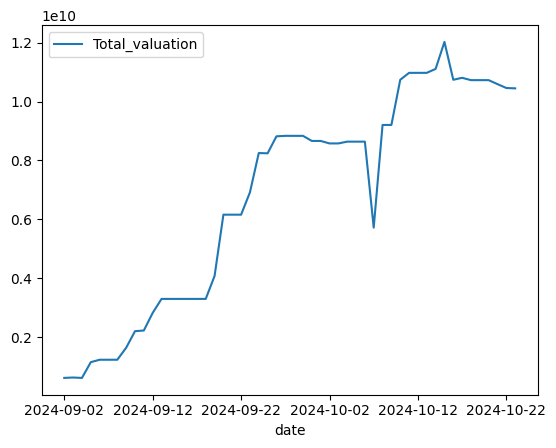

In [6]:
ts.valuation.plot()

In [3]:
stock = Stock(df=trades.dfs[trades.tickers[0]])
stock.timeseries
stock.valuation

,valuation: 003030 KS
date,
2024-09-02,1.585800e+08
2024-09-03,1.638000e+08
2024-09-04,1.584000e+08
2024-09-05,3.000500e+08
2024-09-06,3.017500e+08
2024-09-07,3.017500e+08
2024-09-08,3.017500e+08
2024-09-09,3.843400e+08
2024-09-10,4.017600e+08


In [4]:
valuations = []
for k, df in trades.dfs.items():
    stock = Stock(df=df)
    print(stock.ticker)
    valuation = stock.valuation
    valuations.append(valuation)
valuations

003030 KS
007340 KS
271560 KS
282690 KS
000660 KS
023160 KS
316140 KS
006040 KS


[            valuation: 003030 KS
 date                            
 2024-09-02          1.585800e+08
 2024-09-03          1.638000e+08
 2024-09-04          1.584000e+08
 2024-09-05          3.000500e+08
 2024-09-06          3.017500e+08
 2024-09-07          3.017500e+08
 2024-09-08          3.017500e+08
 2024-09-09          3.843400e+08
 2024-09-10          4.017600e+08
 2024-09-11          4.005600e+08
 2024-09-12          4.801500e+08
 2024-09-13          5.328900e+08
 2024-09-14          5.328900e+08
 2024-09-15          5.328900e+08
 2024-09-16          5.328900e+08
 2024-09-17          5.328900e+08
 2024-09-18          5.328900e+08
 2024-09-19          6.838200e+08
 2024-09-20          9.348130e+08
 2024-09-21          9.348130e+08
 2024-09-22          9.348130e+08
 2024-09-23          9.563678e+08
 2024-09-24          1.099784e+09
 2024-09-25          1.063565e+09
 2024-09-26          1.132611e+09
 2024-09-27          1.082820e+09
 2024-09-28          1.082820e+09
 2024-09-29   

In [13]:
df = pd.concat(valuations, axis=1).fillna(0)
df

,valuation: 003030 KS,valuation: 007340 KS,valuation: 271560 KS,valuation: 282690 KS,valuation: 000660 KS,valuation: 023160 KS,valuation: 316140 KS,valuation: 006040 KS
date,,,,,,,,
2024-09-02,1.585800e+08,2.205000e+08,2.008600e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0
2024-09-03,1.638000e+08,2.312500e+08,1.973400e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0
2024-09-04,1.584000e+08,2.252500e+08,1.951400e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0
2024-09-05,3.000500e+08,4.595000e+08,3.548000e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0
2024-09-06,3.017500e+08,5.424000e+08,3.524000e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0
2024-09-07,3.017500e+08,5.424000e+08,3.524000e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0
2024-09-08,3.017500e+08,5.424000e+08,3.524000e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0
2024-09-09,3.843400e+08,7.753602e+08,4.440000e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0
2024-09-10,4.017600e+08,1.054617e+09,5.238000e+08,33750000.0,1.866000e+08,0.0,0.000000e+00,0.0


<Axes: xlabel='date'>

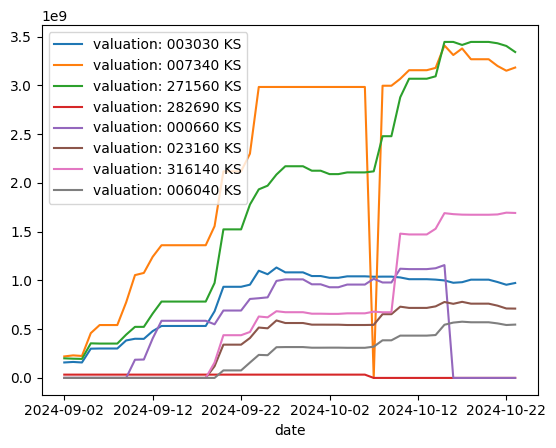

In [14]:
df.plot()

In [8]:
valuations[0]

,valuation: 003030 KS
date,
2024-09-02,1.585800e+08
2024-09-03,1.638000e+08
2024-09-04,1.584000e+08
2024-09-05,3.000500e+08
2024-09-06,3.017500e+08
2024-09-07,3.017500e+08
2024-09-08,3.017500e+08
2024-09-09,3.843400e+08
2024-09-10,4.017600e+08


In [10]:
valuations[5]

,valuation: 023160 KS
date,
2024-09-19,119935000.0
2024-09-20,341220000.0
2024-09-21,341220000.0
2024-09-22,341220000.0
2024-09-23,409080000.0
2024-09-24,516600000.0
2024-09-25,508900000.0
2024-09-26,589600000.0
2024-09-27,563200000.0


In [ ]:
stock_data = StockData(df=trades.dfs[trades.tickers[1]])
ts_stock = stock_data.timeseries
ts_stock = ts_stock[['date', 'valuation']].set_index('date')
ts_stock = ts_stock[~ts_stock.index.duplicated(keep='last')]
ts_stock.columns = [f'valuation: {stock_data.ticker}']
ts_stock

In [15]:
df = ts_stock[['date', 'valuation']].set_index('date')
df = df[~df.index.duplicated(keep='last')]
df = 
df

,valuation
date,
2024-09-02,2.205000e+08
2024-09-03,2.312500e+08
2024-09-04,2.252500e+08
2024-09-05,4.595000e+08
2024-09-06,5.424000e+08
2024-09-07,5.424000e+08
2024-09-08,5.424000e+08
2024-09-09,7.753602e+08
2024-09-10,1.054617e+09


In [3]:
trades.df

,date,ticker,name,type,num_shares,price_trade,amount_trade,delta_shares,cash_flow
0,2024-09-02,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,900,177645.666667,1.600410e+08,900,-1.600410e+08
1,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,88110.280000,2.204960e+08,2500,-2.204960e+08
2,2024-09-02,271560 KS,ORION CORP/REPUBLIC OF KOREA,Buy,2200,91495.772727,2.014920e+08,2200,-2.014920e+08
3,2024-09-02,282690 KS,DONG AH TIRE & RUBBER CO LTD,Buy,2500,13007.988000,3.255249e+07,2500,-3.255249e+07
4,2024-09-05,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,800,175209.750000,1.403080e+08,800,-1.403080e+08
...,...,...,...,...,...,...,...,...,...
70,2024-10-15,023160 KS,TK CORPORATION,Buy,2500,14202.660000,3.554216e+07,2500,-3.554216e+07
71,2024-10-15,271560 KS,ORION CORP/REPUBLIC OF KOREA,Buy,3500,100215.028571,3.511034e+08,3500,-3.511034e+08
72,2024-10-15,316140 KS,WOORI FINANCIAL GROUP INC,Buy,9500,16589.246316,1.577554e+08,9500,-1.577554e+08
73,2024-10-15,006040 KS,DONGWON INDUSTRIES CO LTD,Buy,3150,32989.666667,1.040214e+08,3150,-1.040214e+08


In [4]:
tickers = trades.tickers
tickers

array(['003030 KS', '007340 KS', '271560 KS', '282690 KS', '000660 KS',
       '023160 KS', '316140 KS', '006040 KS'], dtype=object)

In [5]:
trades.dfs

{'003030 KS':           date     ticker                      name type  num_shares  \
 0   2024-09-02  003030 KS  SEAH STEEL HOLDINGS CORP  Buy         900   
 1   2024-09-05  003030 KS  SEAH STEEL HOLDINGS CORP  Buy         800   
 2   2024-09-09  003030 KS  SEAH STEEL HOLDINGS CORP  Buy         500   
 3   2024-09-10  003030 KS  SEAH STEEL HOLDINGS CORP  Buy         200   
 4   2024-09-12  003030 KS  SEAH STEEL HOLDINGS CORP  Buy         350   
 5   2024-09-13  003030 KS  SEAH STEEL HOLDINGS CORP  Buy         350   
 6   2024-09-19  003030 KS  SEAH STEEL HOLDINGS CORP  Buy         699   
 7   2024-09-20  003030 KS  SEAH STEEL HOLDINGS CORP  Buy        1200   
 8   2024-09-23  003030 KS  SEAH STEEL HOLDINGS CORP  Buy         250   
 9   2024-09-24  003030 KS  SEAH STEEL HOLDINGS CORP  Buy         500   
 10  2024-09-26  003030 KS  SEAH STEEL HOLDINGS CORP  Buy         250   
 
       price_trade  amount_trade  delta_shares    cash_flow  cash_flow_cum  \
 0   177645.666667   160040981.

In [6]:
df = trades.dfs[trades.tickers[0]]
df

,date,ticker,name,type,num_shares,price_trade,amount_trade,delta_shares,cash_flow,cash_flow_cum,num_shares_cum,price_average
0,2024-09-02,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,900,177645.666667,160040981.0,900,-160040981.0,-1.600410e+08,900,177823.31
1,2024-09-05,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,800,175209.750000,140307968.0,800,-140307968.0,-3.003489e+08,1700,176675.85
2,2024-09-09,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,500,174271.000000,87222636.0,500,-87222636.0,-3.875716e+08,2200,176168.90
3,2024-09-10,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,200,167672.000000,33567934.0,200,-33567934.0,-4.211395e+08,2400,175474.80
4,2024-09-12,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,350,174357.714286,61086225.0,350,-61086225.0,-4.822257e+08,2750,175354.82
5,2024-09-13,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,350,171938.857143,60238779.0,350,-60238779.0,-5.424645e+08,3100,174988.56
6,2024-09-19,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,699,179751.359084,125771846.0,699,-125771846.0,-6.682364e+08,3799,175897.96
7,2024-09-20,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,1200,185050.583333,222282761.0,1200,-222282761.0,-8.905191e+08,4999,178139.45
8,2024-09-23,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,250,184116.400000,46075129.0,250,-46075129.0,-9.365943e+08,5249,178432.89
9,2024-09-24,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,500,189070.400000,94629735.0,500,-94629735.0,-1.031224e+09,5749,179374.50


In [7]:
df = trades.dfs[trades.tickers[1]]
stock_data = StockData(df=df)
stock_data

In [8]:
stock_data.ticker

'007340 KS'

In [9]:
stock_data.timeseries

,date,ticker,name,num_shares_cum,price_trade,price_average,total_amount,realization,price_last,valuation,pl
0,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,2500.0,88110.280000,88198.39,2.204960e+08,0.000000e+00,88200.0,2.205000e+08,4.025000e+03
1,2024-09-03,007340 KS,DN AUTOMOTIVE CORP,2500.0,88110.280000,88198.39,2.204960e+08,0.000000e+00,92500.0,2.312500e+08,1.075402e+07
2,2024-09-04,007340 KS,DN AUTOMOTIVE CORP,2500.0,88110.280000,88198.39,2.204960e+08,0.000000e+00,90100.0,2.252500e+08,4.754025e+06
3,2024-09-05,007340 KS,DN AUTOMOTIVE CORP,5000.0,91637.240000,89963.63,4.498182e+08,0.000000e+00,91900.0,4.595000e+08,9.681850e+06
4,2024-09-06,007340 KS,DN AUTOMOTIVE CORP,6000.0,90969.100000,90146.37,5.408782e+08,0.000000e+00,90400.0,5.424000e+08,1.521780e+06
5,2024-09-07,007340 KS,DN AUTOMOTIVE CORP,6000.0,90969.100000,90146.37,5.408782e+08,0.000000e+00,90400.0,5.424000e+08,1.521780e+06
6,2024-09-08,007340 KS,DN AUTOMOTIVE CORP,6000.0,90969.100000,90146.37,5.408782e+08,0.000000e+00,90400.0,5.424000e+08,1.521780e+06
7,2024-09-09,007340 KS,DN AUTOMOTIVE CORP,8231.0,93556.611385,91096.07,7.498118e+08,0.000000e+00,94200.0,7.753602e+08,2.554845e+07
8,2024-09-10,007340 KS,DN AUTOMOTIVE CORP,11731.0,90417.457143,90920.58,1.066589e+09,0.000000e+00,89900.0,1.054617e+09,-1.197242e+07
9,2024-09-11,007340 KS,DN AUTOMOTIVE CORP,11731.0,90417.457143,90920.58,1.066589e+09,0.000000e+00,91800.0,1.076906e+09,1.031648e+07


In [10]:
stock_data.df

,date,ticker,name,type,num_shares,price_trade,amount_trade,delta_shares,cash_flow,cash_flow_cum,num_shares_cum,price_average
0,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,88110.280000,2.204960e+08,2500,-2.204960e+08,-2.204960e+08,2500,88198.39
1,2024-09-05,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,91637.240000,2.293222e+08,2500,-2.293222e+08,-4.498182e+08,5000,89963.63
2,2024-09-06,007340 KS,DN AUTOMOTIVE CORP,Buy,1000,90969.100000,9.106007e+07,1000,-9.106007e+07,-5.408782e+08,6000,90146.37
3,2024-09-09,007340 KS,DN AUTOMOTIVE CORP,Buy,2231,93556.611385,2.089335e+08,2231,-2.089335e+08,-7.498118e+08,8231,91096.07
4,2024-09-10,007340 KS,DN AUTOMOTIVE CORP,Buy,3500,90417.457143,3.167776e+08,3500,-3.167776e+08,-1.066589e+09,11731,90920.58
5,2024-09-12,007340 KS,DN AUTOMOTIVE CORP,Buy,1500,92685.933333,1.391679e+08,1500,-1.391679e+08,-1.205757e+09,13231,91131.23
6,2024-09-13,007340 KS,DN AUTOMOTIVE CORP,Buy,1500,92786.400000,1.393188e+08,1500,-1.393188e+08,-1.345076e+09,14731,91309.21
7,2024-09-19,007340 KS,DN AUTOMOTIVE CORP,Buy,1500,95794.600000,1.438356e+08,1500,-1.438356e+08,-1.488912e+09,16231,91732.59
8,2024-09-20,007340 KS,DN AUTOMOTIVE CORP,Buy,4500,102093.444444,4.598799e+08,4500,-4.598799e+08,-1.948792e+09,20731,94003.74
9,2024-09-23,007340 KS,DN AUTOMOTIVE CORP,Buy,2000,100705.900000,2.016132e+08,2000,-2.016132e+08,-2.150405e+09,22731,94602.29


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

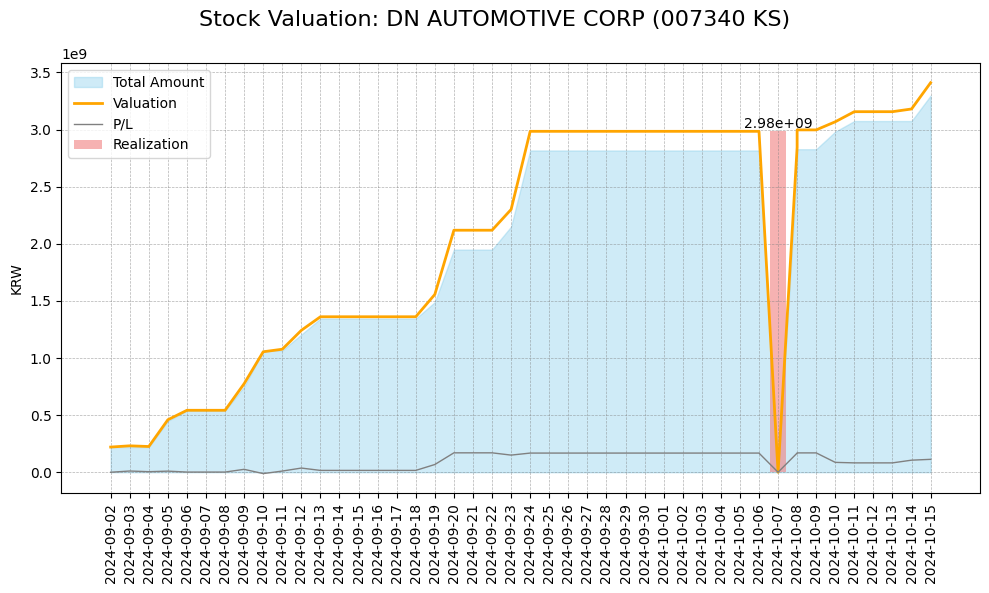

In [11]:
stock_data.plot()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

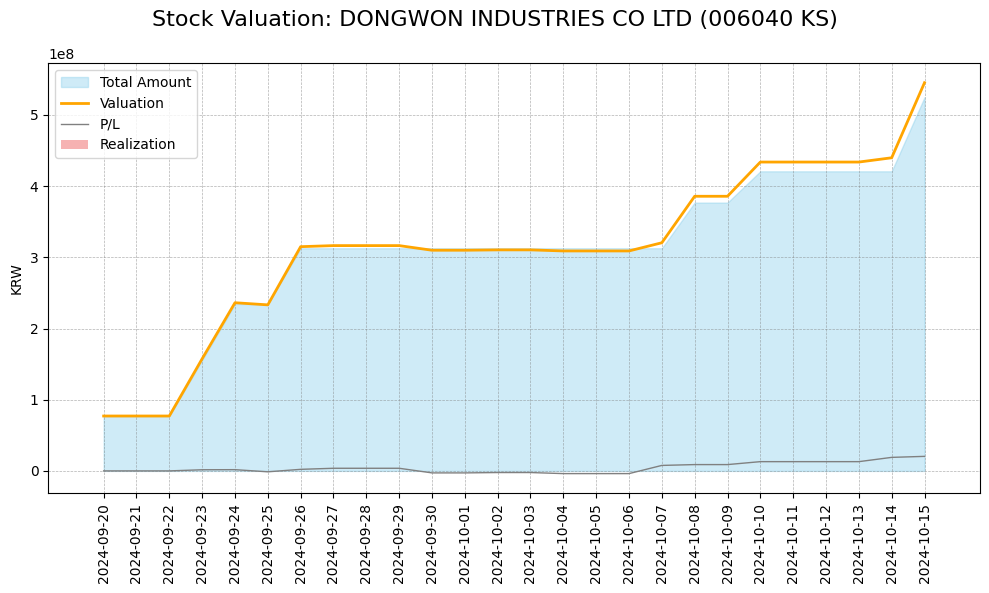

In [21]:
stock_data = StockData(df=trades.dfs[trades.tickers[7]])
stock_data.plot()

In [22]:
ts = Timeseries(trades=trades)
ts

AttributeError: 'Trades' object has no attribute 'pl_buys'

In [6]:
df_stock = trades.dfs[tickers[0]]
df_stock

,date,ticker,name,type,num_shares,price_trade,amount_trade,delta_shares,cash_flow,cash_flow_cum,num_shares_cum,price_average
0,2024-09-02,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,900,177645.666667,160040981.0,900,-160040981.0,-1.600410e+08,900,177823.31
1,2024-09-05,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,800,175209.750000,140307968.0,800,-140307968.0,-3.003489e+08,1700,176675.85
2,2024-09-09,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,500,174271.000000,87222636.0,500,-87222636.0,-3.875716e+08,2200,176168.90
3,2024-09-10,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,200,167672.000000,33567934.0,200,-33567934.0,-4.211395e+08,2400,175474.80
4,2024-09-12,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,350,174357.714286,61086225.0,350,-61086225.0,-4.822257e+08,2750,175354.82
5,2024-09-13,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,350,171938.857143,60238779.0,350,-60238779.0,-5.424645e+08,3100,174988.56
6,2024-09-19,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,699,179751.359084,125771846.0,699,-125771846.0,-6.682364e+08,3799,175897.96
7,2024-09-20,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,1200,185050.583333,222282761.0,1200,-222282761.0,-8.905191e+08,4999,178139.45
8,2024-09-23,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,250,184116.400000,46075129.0,250,-46075129.0,-9.365943e+08,5249,178432.89
9,2024-09-24,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,500,189070.400000,94629735.0,500,-94629735.0,-1.031224e+09,5749,179374.50


In [8]:
df_stock.columns

Index(['date', 'ticker', 'name', 'type', 'num_shares', 'price_trade',
       'amount_trade', 'delta_shares', 'cash_flow', 'cash_flow_cum',
       'num_shares_cum', 'price_average'],
      dtype='object')

In [7]:
stock = StockData(df=df_stock)

ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [7]:
trades.get_df_stock(trades.tickers[3])

,date,ticker,name,num_shares_cum,price_trade,price_average,total_amount,realization,price_last,valuation,pl
0,2024-09-02,282690 KS,DONG AH TIRE & RUBBER CO LTD,2500.0,13007.988,13021.0,32552500.0,0.0,13500.0,33750000.0,1197500.0
1,2024-09-03,282690 KS,DONG AH TIRE & RUBBER CO LTD,2500.0,13007.988,13021.0,32552500.0,0.0,13500.0,33750000.0,1197500.0
2,2024-09-04,282690 KS,DONG AH TIRE & RUBBER CO LTD,2500.0,13007.988,13021.0,32552500.0,0.0,13500.0,33750000.0,1197500.0
3,2024-09-05,282690 KS,DONG AH TIRE & RUBBER CO LTD,2500.0,13007.988,13021.0,32552500.0,0.0,13500.0,33750000.0,1197500.0
4,2024-09-06,282690 KS,DONG AH TIRE & RUBBER CO LTD,2500.0,13007.988,13021.0,32552500.0,0.0,13500.0,33750000.0,1197500.0
5,2024-09-07,282690 KS,DONG AH TIRE & RUBBER CO LTD,2500.0,13007.988,13021.0,32552500.0,0.0,13500.0,33750000.0,1197500.0
6,2024-09-08,282690 KS,DONG AH TIRE & RUBBER CO LTD,2500.0,13007.988,13021.0,32552500.0,0.0,13500.0,33750000.0,1197500.0
7,2024-09-09,282690 KS,DONG AH TIRE & RUBBER CO LTD,2500.0,13007.988,13021.0,32552500.0,0.0,13500.0,33750000.0,1197500.0
8,2024-09-10,282690 KS,DONG AH TIRE & RUBBER CO LTD,2500.0,13007.988,13021.0,32552500.0,0.0,13500.0,33750000.0,1197500.0
9,2024-09-11,282690 KS,DONG AH TIRE & RUBBER CO LTD,2500.0,13007.988,13021.0,32552500.0,0.0,13500.0,33750000.0,1197500.0


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

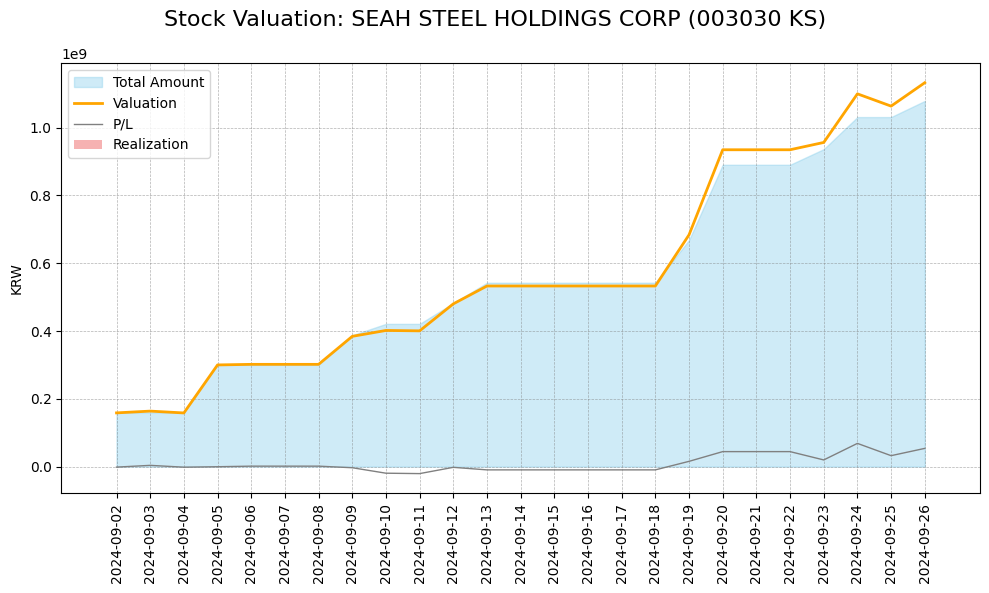

In [11]:
plot_stock(trades.get_df_stock(trades.tickers[0]))

In [9]:
trades.dfs[trades.tickers[0]]

,date,ticker,name,type,num_shares,price_trade,amount_trade,delta_shares,cash_flow,cash_flow_cum,num_shares_cum,price_average
0,2024-09-02,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,900,177645.666667,160040981.0,900,-160040981.0,-1.600410e+08,900,177823.31
1,2024-09-05,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,800,175209.750000,140307968.0,800,-140307968.0,-3.003489e+08,1700,176675.85
2,2024-09-09,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,500,174271.000000,87222636.0,500,-87222636.0,-3.875716e+08,2200,176168.90
3,2024-09-10,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,200,167672.000000,33567934.0,200,-33567934.0,-4.211395e+08,2400,175474.80
4,2024-09-12,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,350,174357.714286,61086225.0,350,-61086225.0,-4.822257e+08,2750,175354.82
5,2024-09-13,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,350,171938.857143,60238779.0,350,-60238779.0,-5.424645e+08,3100,174988.56
6,2024-09-19,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,699,179751.359084,125771846.0,699,-125771846.0,-6.682364e+08,3799,175897.96
7,2024-09-20,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,1200,185050.583333,222282761.0,1200,-222282761.0,-8.905191e+08,4999,178139.45
8,2024-09-23,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,250,184116.400000,46075129.0,250,-46075129.0,-9.365943e+08,5249,178432.89
9,2024-09-24,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,500,189070.400000,94629735.0,500,-94629735.0,-1.031224e+09,5749,179374.50


In [10]:
plot_stock(trades.dfs, trades.tickers[0])

AttributeError: 'dict' object has no attribute 'iloc'

In [7]:
df = trades.dfs[trades.tickers[4]]
df

,date,ticker,name,type,num_shares,price_trade,amount_trade,delta_shares,cash_flow,cash_flow_cum,num_shares_cum,price_average
0,2024-09-10,000660 KS,SK HYNIX INC,Buy,1200,155763.750000,1.871034e+08,1200,-1.871034e+08,-187103416.0,1200,155919.51
1,2024-09-12,000660 KS,SK HYNIX INC,Buy,1200,169193.000000,2.032346e+08,1200,-2.032346e+08,-390338048.0,2400,162640.85
2,2024-09-13,000660 KS,SK HYNIX INC,Buy,1200,162684.416667,1.954165e+08,1200,-1.954165e+08,-585754569.0,3600,162709.60
3,2024-09-20,000660 KS,SK HYNIX INC,Buy,800,157177.625000,1.258678e+08,800,-1.258678e+08,-711622411.0,4400,161732.37
4,2024-09-23,000660 KS,SK HYNIX INC,Buy,600,161567.000000,9.703714e+07,600,-9.703714e+07,-808659551.0,5000,161731.91
5,2024-09-26,000660 KS,SK HYNIX INC,Buy,500,179272.600000,8.972594e+07,500,-8.972594e+07,-898385487.0,5500,163342.82
6,2024-10-10,000660 KS,SK HYNIX INC,Buy,500,185651.400000,9.291853e+07,500,-9.291853e+07,-991304013.0,6000,165217.34
7,2024-10-16,000660 KS,SK HYNIX INC,Sell,6000,189251.983333,1.136647e+09,-6000,1.136647e+09,145343399.0,0,0.00


In [8]:
df_nums = df[['date', 'ticker', 'name', 'num_shares_cum', 'price_trade', 'price_average']].copy()
df_nums.loc[:, 'total_amount'] = df_nums['num_shares_cum'] * df_nums['price_average']
# df_nums.loc[:, 'valuation'] = df_nums['num_shares_cum'] * df_nums['price_average']
df_nums.loc[:, 'realization'] = df['cashflow'].apply(lambda x: x if x > 0 else 0)
df_nums

,date,ticker,name,num_shares_cum,price_trade,price_average,total_amount,realization
0,2024-09-10,000660 KS,SK HYNIX INC,1200,155763.750000,155919.51,187103412.0,0.000000e+00
1,2024-09-12,000660 KS,SK HYNIX INC,2400,169193.000000,162640.85,390338040.0,0.000000e+00
2,2024-09-13,000660 KS,SK HYNIX INC,3600,162684.416667,162709.60,585754560.0,0.000000e+00
3,2024-09-20,000660 KS,SK HYNIX INC,4400,157177.625000,161732.37,711622428.0,0.000000e+00
4,2024-09-23,000660 KS,SK HYNIX INC,5000,161567.000000,161731.91,808659550.0,0.000000e+00
5,2024-09-26,000660 KS,SK HYNIX INC,5500,179272.600000,163342.82,898385510.0,0.000000e+00
6,2024-10-10,000660 KS,SK HYNIX INC,6000,185651.400000,165217.34,991304040.0,0.000000e+00
7,2024-10-16,000660 KS,SK HYNIX INC,0,189251.983333,0.00,0.0,1.136647e+09


In [9]:
df_all_dates = pd.DataFrame({'date': get_date_range(start_date_str=df_nums['date'].min(), end_date_str=df_nums['date'].max())})
df = pd.merge(df_all_dates, df_nums, on='date', how='left').sort_values('date').ffill()
df

,date,ticker,name,num_shares_cum,price_trade,price_average,total_amount,realization
0,2024-09-10,000660 KS,SK HYNIX INC,1200.0,155763.750000,155919.51,187103412.0,0.000000e+00
1,2024-09-11,000660 KS,SK HYNIX INC,1200.0,155763.750000,155919.51,187103412.0,0.000000e+00
2,2024-09-12,000660 KS,SK HYNIX INC,2400.0,169193.000000,162640.85,390338040.0,0.000000e+00
3,2024-09-13,000660 KS,SK HYNIX INC,3600.0,162684.416667,162709.60,585754560.0,0.000000e+00
4,2024-09-14,000660 KS,SK HYNIX INC,3600.0,162684.416667,162709.60,585754560.0,0.000000e+00
5,2024-09-15,000660 KS,SK HYNIX INC,3600.0,162684.416667,162709.60,585754560.0,0.000000e+00
6,2024-09-16,000660 KS,SK HYNIX INC,3600.0,162684.416667,162709.60,585754560.0,0.000000e+00
7,2024-09-17,000660 KS,SK HYNIX INC,3600.0,162684.416667,162709.60,585754560.0,0.000000e+00
8,2024-09-18,000660 KS,SK HYNIX INC,3600.0,162684.416667,162709.60,585754560.0,0.000000e+00
9,2024-09-19,000660 KS,SK HYNIX INC,3600.0,162684.416667,162709.60,585754560.0,0.000000e+00


In [10]:
price_of_ticker = get_price_by_ticker(ticker='000660 KS')
price_of_ticker

,price_last
date,
2001-01-02,89118
2001-01-03,89511
2001-01-04,102859
2001-01-05,118170
2001-01-08,120525
...,...
2024-10-10,186700
2024-10-11,186000
2024-10-14,187500


In [11]:
price_of_ticker = get_price_by_ticker(ticker='000660 KS')
df_merge = df.merge(price_of_ticker, how='left', left_on='date', right_index=True).ffill()
df_merge['valuation'] = df_merge['num_shares_cum'] * df_merge['price_last']
df_merge['pl'] = df_merge['valuation'] - df_merge['total_amount']
df_merge

,date,ticker,name,num_shares_cum,price_trade,price_average,total_amount,realization,price_last,valuation,pl
0,2024-09-10,000660 KS,SK HYNIX INC,1200.0,155763.750000,155919.51,187103412.0,0.000000e+00,155500.0,1.866000e+08,-503412.0
1,2024-09-11,000660 KS,SK HYNIX INC,1200.0,155763.750000,155919.51,187103412.0,0.000000e+00,157200.0,1.886400e+08,1536588.0
2,2024-09-12,000660 KS,SK HYNIX INC,2400.0,169193.000000,162640.85,390338040.0,0.000000e+00,168800.0,4.051200e+08,14781960.0
3,2024-09-13,000660 KS,SK HYNIX INC,3600.0,162684.416667,162709.60,585754560.0,0.000000e+00,162800.0,5.860800e+08,325440.0
4,2024-09-14,000660 KS,SK HYNIX INC,3600.0,162684.416667,162709.60,585754560.0,0.000000e+00,162800.0,5.860800e+08,325440.0
5,2024-09-15,000660 KS,SK HYNIX INC,3600.0,162684.416667,162709.60,585754560.0,0.000000e+00,162800.0,5.860800e+08,325440.0
6,2024-09-16,000660 KS,SK HYNIX INC,3600.0,162684.416667,162709.60,585754560.0,0.000000e+00,162800.0,5.860800e+08,325440.0
7,2024-09-17,000660 KS,SK HYNIX INC,3600.0,162684.416667,162709.60,585754560.0,0.000000e+00,162800.0,5.860800e+08,325440.0
8,2024-09-18,000660 KS,SK HYNIX INC,3600.0,162684.416667,162709.60,585754560.0,0.000000e+00,162800.0,5.860800e+08,325440.0
9,2024-09-19,000660 KS,SK HYNIX INC,3600.0,162684.416667,162709.60,585754560.0,0.000000e+00,152800.0,5.500800e+08,-35674560.0


In [12]:
df_merge[['date', 'total_amount', 'realization', 'valuation']]

,date,total_amount,realization,valuation
0,2024-09-10,187103412.0,0.000000e+00,1.866000e+08
1,2024-09-11,187103412.0,0.000000e+00,1.886400e+08
2,2024-09-12,390338040.0,0.000000e+00,4.051200e+08
3,2024-09-13,585754560.0,0.000000e+00,5.860800e+08
4,2024-09-14,585754560.0,0.000000e+00,5.860800e+08
5,2024-09-15,585754560.0,0.000000e+00,5.860800e+08
6,2024-09-16,585754560.0,0.000000e+00,5.860800e+08
7,2024-09-17,585754560.0,0.000000e+00,5.860800e+08
8,2024-09-18,585754560.0,0.000000e+00,5.860800e+08
9,2024-09-19,585754560.0,0.000000e+00,5.500800e+08


In [13]:
def plot_stock(dfs, ticker):
    df = dfs['ticker']
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.fill_between(df['date'], df['total_amount'], color='skyblue', alpha=0.4, label='Total Amount', where=np.isfinite(df['total_amount']))    
    bars = ax1.bar(df['date'], df['realization'], color='lightcoral', alpha=0.6, label='Realization')

    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Only label positive bars
            ax1.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2e}', ha='center', va='bottom', color='black', fontsize=10)

    ax1.plot(df['date'], df['valuation'], color='orange', label='Valuation', linewidth=2)    
    ax1.plot(df['date'], df['pl'], color='gray', label='P/L', linewidth=1)
    ax1.set_ylabel('KRW', color='black')
    plt.xticks(rotation=90, ha='center')

    ax1.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.6)

    fig.suptitle(f'Chart: Stock Valuation: {ticker}', fontsize=16, color='black')
    ax1.legend(loc='upper left')
    plt.tight_layout()

    plt.show()

plot_stock(df_merge)


TypeError: plot_stock() missing 1 required positional argument: 'ticker'

In [73]:
dfs[trades.tickers[4]]

NameError: name 'dfs' is not defined

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

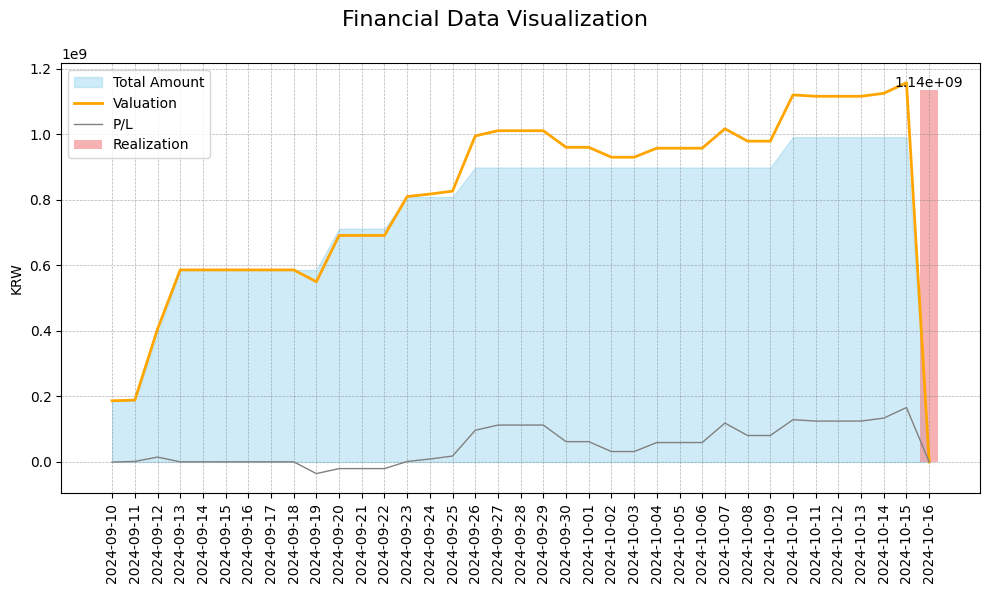

In [72]:
def plot_stock(df):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.fill_between(df['date'], df['total_amount'], color='skyblue', alpha=0.4, label='Total Amount', where=np.isfinite(df['total_amount']))    
    bars = ax1.bar(df['date'], df['realization'], color='lightcoral', alpha=0.6, label='Realization')

    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Only label positive bars
            ax1.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2e}', ha='center', va='bottom', color='black', fontsize=10)

    ax1.plot(df['date'], df['valuation'], color='orange', label='Valuation', linewidth=2)    
    ax1.plot(df['date'], df['pl'], color='gray', label='P/L', linewidth=1)
    ax1.set_ylabel('KRW', color='black')
    plt.xticks(rotation=90, ha='center')

    ax1.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.6)

    fig.suptitle('Financial Data Visualization', fontsize=16, color='black')
    ax1.legend(loc='upper left')
    plt.tight_layout()

    plt.show()

plot_stock(df_merge)


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

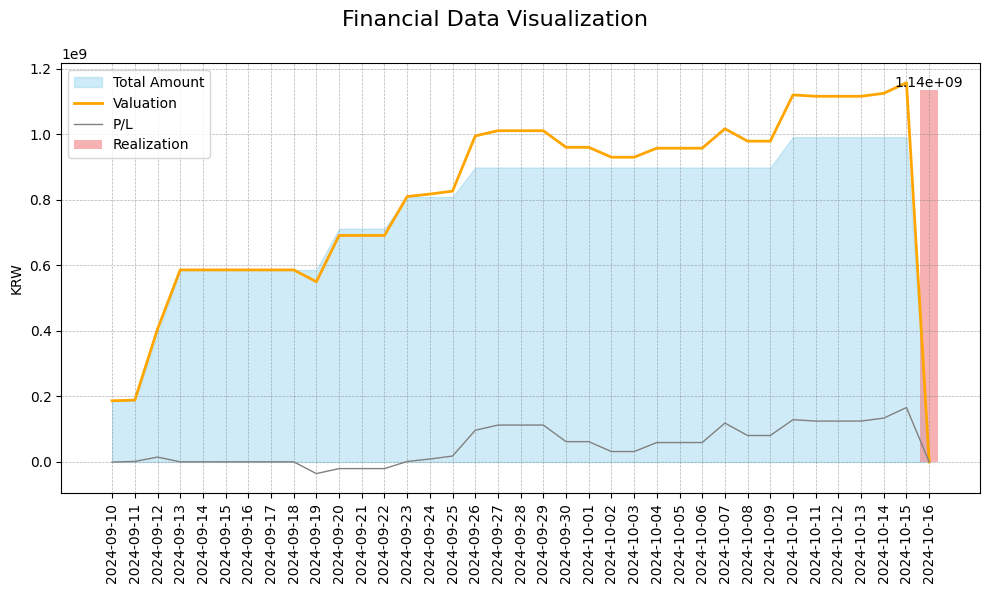

In [70]:
plot_stock(df_merge)


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

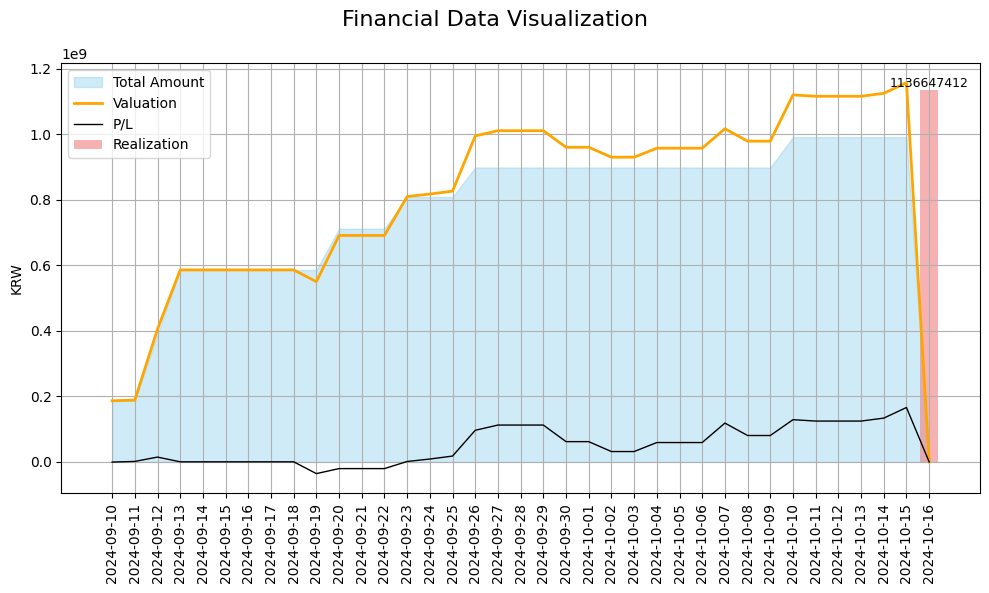

In [64]:
# 막대 차트 위에 라벨을 추가한 수정된 함수
def plot_stock_with_labels(df):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Area chart for 'total_amount'
    ax1.fill_between(df['date'], df['total_amount'], color='skyblue', alpha=0.4, label='Total Amount', where=np.isfinite(df['total_amount']))
    
    # Bar chart for 'realization'
    bars = ax1.bar(df['date'], df['realization'], color='lightcoral', alpha=0.6, label='Realization')
    
    # 막대 위에 라벨 표시
    for bar in bars:
        yval = bar.get_height()
        if yval != 0:  # 값이 0이 아닌 경우에만 라벨 표시
            ax1.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.0f}', ha='center', va='bottom', fontsize=9, color='black')

    # Line chart for 'valuation'
    ax1.plot(df['date'], df['valuation'], color='orange', label='Valuation', linewidth=2)
    
    # Line chart for 'pl' (thin black line)
    ax1.plot(df['date'], df['pl'], color='black', label='P/L', linewidth=1)

    # Set Y-axis label as KRW on the left axis
    ax1.set_ylabel('KRW', color='black')

    # Set X-axis ticks with date labels vertical
    plt.xticks(rotation=90, ha='center')

    # Set the grid
    ax1.grid(True)

    # Set title and legends
    fig.suptitle('Financial Data Visualization', fontsize=16, color='black')
    ax1.legend(loc='upper left')

    # Ensure the layout is clean
    plt.tight_layout()

    plt.show()

# Call the updated plotting function
plot_stock_with_labels(df_merge)


In [6]:
stock = trades.dfs['007340 KS']
stock

,date,ticker,name,type,num_shares,price_trade,amount_trade,delta_shares,cash_flow,cash_flow_cum,num_shares_cum,price_average
0,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,88110.280000,2.204960e+08,2500,-2.204960e+08,-2.204960e+08,2500,88198.39
1,2024-09-05,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,91637.240000,2.293222e+08,2500,-2.293222e+08,-4.498182e+08,5000,89963.63
2,2024-09-06,007340 KS,DN AUTOMOTIVE CORP,Buy,1000,90969.100000,9.106007e+07,1000,-9.106007e+07,-5.408782e+08,6000,90146.37
3,2024-09-09,007340 KS,DN AUTOMOTIVE CORP,Buy,2231,93556.611385,2.089335e+08,2231,-2.089335e+08,-7.498118e+08,8231,91096.07
4,2024-09-10,007340 KS,DN AUTOMOTIVE CORP,Buy,3500,90417.457143,3.167776e+08,3500,-3.167776e+08,-1.066589e+09,11731,90920.58
5,2024-09-12,007340 KS,DN AUTOMOTIVE CORP,Buy,1500,92685.933333,1.391679e+08,1500,-1.391679e+08,-1.205757e+09,13231,91131.23
6,2024-09-13,007340 KS,DN AUTOMOTIVE CORP,Buy,1500,92786.400000,1.393188e+08,1500,-1.393188e+08,-1.345076e+09,14731,91309.21
7,2024-09-19,007340 KS,DN AUTOMOTIVE CORP,Buy,1500,95794.600000,1.438356e+08,1500,-1.438356e+08,-1.488912e+09,16231,91732.59
8,2024-09-20,007340 KS,DN AUTOMOTIVE CORP,Buy,4500,102093.444444,4.598799e+08,4500,-4.598799e+08,-1.948792e+09,20731,94003.74
9,2024-09-23,007340 KS,DN AUTOMOTIVE CORP,Buy,2000,100705.900000,2.016132e+08,2000,-2.016132e+08,-2.150405e+09,22731,94602.29


In [17]:
from shining_pebbles import get_today, get_date_range

cols_to_keep = ['date', 'ticker', 'num_shares_cum', 'price_average']
df = stock[cols_to_keep]
df_all_dates = pd.DataFrame({'date': get_date_range(start_date_str=df['date'].min(), end_date_str=get_today())})
df = pd.merge(df_all_dates, df, on='date', how='left').sort_values('date')
df = df.ffill()
price = get_price_by_ticker(ticker='007340 KS')
df = df.merge(price, how='left', left_on='date', right_index=True).ffill()
df['acquisition'] = df['num_shares_cum'] * df['price_average']
df['valuation'] = df['num_shares_cum'] * df['price_last']
df['pl'] = df['valuation'] - df['acquisition']
df

,date,ticker,num_shares_cum,price_average,price_last,acquisition,valuation,pl
0,2024-09-02,007340 KS,2500.0,88198.39,88200.0,2.204960e+08,2.205000e+08,4.025000e+03
1,2024-09-03,007340 KS,2500.0,88198.39,92500.0,2.204960e+08,2.312500e+08,1.075402e+07
2,2024-09-04,007340 KS,2500.0,88198.39,90100.0,2.204960e+08,2.252500e+08,4.754025e+06
3,2024-09-05,007340 KS,5000.0,89963.63,91900.0,4.498182e+08,4.595000e+08,9.681850e+06
4,2024-09-06,007340 KS,6000.0,90146.37,90400.0,5.408782e+08,5.424000e+08,1.521780e+06
5,2024-09-07,007340 KS,6000.0,90146.37,90400.0,5.408782e+08,5.424000e+08,1.521780e+06
6,2024-09-08,007340 KS,6000.0,90146.37,90400.0,5.408782e+08,5.424000e+08,1.521780e+06
7,2024-09-09,007340 KS,8231.0,91096.07,94200.0,7.498118e+08,7.753602e+08,2.554845e+07
8,2024-09-10,007340 KS,11731.0,90920.58,89900.0,1.066589e+09,1.054617e+09,-1.197242e+07
9,2024-09-11,007340 KS,11731.0,90920.58,91800.0,1.066589e+09,1.076906e+09,1.031648e+07


In [ ]:
df = df.set_index

In [11]:
df = df.ffill()
price = get_price_by_ticker(ticker='007340 KS')
df = df.merge(price, how='left', left_on='date', right_index=True).ffill()
df['acquisition'] = df['num_shares_cum'] * df['price_average']
df['valuation'] = df['num_shares_cum'] * df['price_last']

df

,date,ticker,num_shares_cum,price_average
0,2024-09-02,007340 KS,2500.0,88198.39
1,2024-09-03,007340 KS,2500.0,88198.39
2,2024-09-04,007340 KS,2500.0,88198.39
3,2024-09-05,007340 KS,5000.0,89963.63
4,2024-09-06,007340 KS,6000.0,90146.37
5,2024-09-07,007340 KS,6000.0,90146.37
6,2024-09-08,007340 KS,6000.0,90146.37
7,2024-09-09,007340 KS,8231.0,91096.07
8,2024-09-10,007340 KS,11731.0,90920.58
9,2024-09-11,007340 KS,11731.0,90920.58


In [12]:
price = get_price_by_ticker(ticker='007340 KS')
df = df.merge(price, how='left', left_on='date', right_index=True).ffill()
df['acquisition'] = df['num_shares_cum'] * df['price_average']
df['valuation'] = df['num_shares_cum'] * df['price_last']
df



,price_last
date,
2001-01-02,2272
2001-01-03,2272
2001-01-04,2281
2001-01-05,2272
2001-01-08,2320
...,...
2024-10-10,18680
2024-10-11,18650
2024-10-14,18790


In [14]:
df = df.merge(price, how='left', left_on='date', right_index=True).ffill()
df

,date,ticker,num_shares_cum,price_average,price_last
0,2024-09-02,007340 KS,2500.0,88198.39,88200.0
1,2024-09-03,007340 KS,2500.0,88198.39,92500.0
2,2024-09-04,007340 KS,2500.0,88198.39,90100.0
3,2024-09-05,007340 KS,5000.0,89963.63,91900.0
4,2024-09-06,007340 KS,6000.0,90146.37,90400.0
5,2024-09-07,007340 KS,6000.0,90146.37,90400.0
6,2024-09-08,007340 KS,6000.0,90146.37,90400.0
7,2024-09-09,007340 KS,8231.0,91096.07,94200.0
8,2024-09-10,007340 KS,11731.0,90920.58,89900.0
9,2024-09-11,007340 KS,11731.0,90920.58,91800.0


In [15]:
df['acquisition'] = df['num_shares_cum'] * df['price_average']
df['valuation'] = df['num_shares_cum'] * df['price_last']
df


,date,ticker,num_shares_cum,price_average,price_last,acquisition,valuation
0,2024-09-02,007340 KS,2500.0,88198.39,88200.0,2.204960e+08,2.205000e+08
1,2024-09-03,007340 KS,2500.0,88198.39,92500.0,2.204960e+08,2.312500e+08
2,2024-09-04,007340 KS,2500.0,88198.39,90100.0,2.204960e+08,2.252500e+08
3,2024-09-05,007340 KS,5000.0,89963.63,91900.0,4.498182e+08,4.595000e+08
4,2024-09-06,007340 KS,6000.0,90146.37,90400.0,5.408782e+08,5.424000e+08
5,2024-09-07,007340 KS,6000.0,90146.37,90400.0,5.408782e+08,5.424000e+08
6,2024-09-08,007340 KS,6000.0,90146.37,90400.0,5.408782e+08,5.424000e+08
7,2024-09-09,007340 KS,8231.0,91096.07,94200.0,7.498118e+08,7.753602e+08
8,2024-09-10,007340 KS,11731.0,90920.58,89900.0,1.066589e+09,1.054617e+09
9,2024-09-11,007340 KS,11731.0,90920.58,91800.0,1.066589e+09,1.076906e+09


<Axes: >

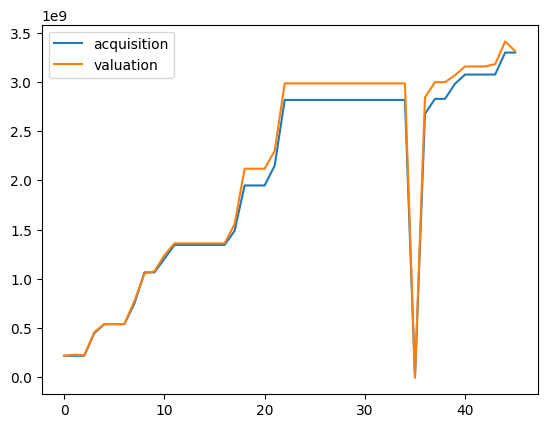

In [16]:
df[['acquisition', 'valuation']].plot()

In [8]:
import pandas as pd

def map_df_to_data(df):
    df = df.reset_index() if df.index.name else df
    data = df.to_dict(orient='records')
    return data

def map_data_to_df(data):
    df = pd.DataFrame(data)
    return df

In [9]:
df = trades.dfs['007340 KS']
df


,date,ticker,name,type,num_shares,price_trade,amount_trade,delta_shares,cash_flow,cash_flow_cum,num_shares_cum,price_average
0,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,88110.280000,2.204960e+08,2500,-2.204960e+08,-2.204960e+08,2500,88198.39
1,2024-09-05,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,91637.240000,2.293222e+08,2500,-2.293222e+08,-4.498182e+08,5000,89963.63
2,2024-09-06,007340 KS,DN AUTOMOTIVE CORP,Buy,1000,90969.100000,9.106007e+07,1000,-9.106007e+07,-5.408782e+08,6000,90146.37
3,2024-09-09,007340 KS,DN AUTOMOTIVE CORP,Buy,2231,93556.611385,2.089335e+08,2231,-2.089335e+08,-7.498118e+08,8231,91096.07
4,2024-09-10,007340 KS,DN AUTOMOTIVE CORP,Buy,3500,90417.457143,3.167776e+08,3500,-3.167776e+08,-1.066589e+09,11731,90920.58
5,2024-09-12,007340 KS,DN AUTOMOTIVE CORP,Buy,1500,92685.933333,1.391679e+08,1500,-1.391679e+08,-1.205757e+09,13231,91131.23
6,2024-09-13,007340 KS,DN AUTOMOTIVE CORP,Buy,1500,92786.400000,1.393188e+08,1500,-1.393188e+08,-1.345076e+09,14731,91309.21
7,2024-09-19,007340 KS,DN AUTOMOTIVE CORP,Buy,1500,95794.600000,1.438356e+08,1500,-1.438356e+08,-1.488912e+09,16231,91732.59
8,2024-09-20,007340 KS,DN AUTOMOTIVE CORP,Buy,4500,102093.444444,4.598799e+08,4500,-4.598799e+08,-1.948792e+09,20731,94003.74
9,2024-09-23,007340 KS,DN AUTOMOTIVE CORP,Buy,2000,100705.900000,2.016132e+08,2000,-2.016132e+08,-2.150405e+09,22731,94602.29


In [10]:
data = map_df_to_data(df)
data

[{'date': '2024-09-02',
  'ticker': '007340 KS',
  'name': 'DN AUTOMOTIVE CORP',
  'type': 'Buy',
  'num_shares': 2500,
  'price_trade': 88110.28,
  'amount_trade': 220495976.0,
  'delta_shares': 2500,
  'cash_flow': -220495976.0,
  'cash_flow_cum': -220495976.0,
  'num_shares_cum': 2500,
  'price_average': 88198.39},
 {'date': '2024-09-05',
  'ticker': '007340 KS',
  'name': 'DN AUTOMOTIVE CORP',
  'type': 'Buy',
  'num_shares': 2500,
  'price_trade': 91637.24,
  'amount_trade': 229322193.0,
  'delta_shares': 2500,
  'cash_flow': -229322193.0,
  'cash_flow_cum': -449818169.0,
  'num_shares_cum': 5000,
  'price_average': 89963.63},
 {'date': '2024-09-06',
  'ticker': '007340 KS',
  'name': 'DN AUTOMOTIVE CORP',
  'type': 'Buy',
  'num_shares': 1000,
  'price_trade': 90969.1,
  'amount_trade': 91060069.0,
  'delta_shares': 1000,
  'cash_flow': -91060069.0,
  'cash_flow_cum': -540878238.0,
  'num_shares_cum': 6000,
  'price_average': 90146.37},
 {'date': '2024-09-09',
  'ticker': '007340

In [12]:
data[0].keys()

dict_keys(['date', 'ticker', 'name', 'type', 'num_shares', 'price_trade', 'amount_trade', 'delta_shares', 'cash_flow', 'cash_flow_cum', 'num_shares_cum', 'price_average'])

In [11]:
pd.DataFrame(data)

,date,ticker,name,type,num_shares,price_trade,amount_trade,delta_shares,cash_flow,cash_flow_cum,num_shares_cum,price_average
0,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,88110.280000,2.204960e+08,2500,-2.204960e+08,-2.204960e+08,2500,88198.39
1,2024-09-05,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,91637.240000,2.293222e+08,2500,-2.293222e+08,-4.498182e+08,5000,89963.63
2,2024-09-06,007340 KS,DN AUTOMOTIVE CORP,Buy,1000,90969.100000,9.106007e+07,1000,-9.106007e+07,-5.408782e+08,6000,90146.37
3,2024-09-09,007340 KS,DN AUTOMOTIVE CORP,Buy,2231,93556.611385,2.089335e+08,2231,-2.089335e+08,-7.498118e+08,8231,91096.07
4,2024-09-10,007340 KS,DN AUTOMOTIVE CORP,Buy,3500,90417.457143,3.167776e+08,3500,-3.167776e+08,-1.066589e+09,11731,90920.58
5,2024-09-12,007340 KS,DN AUTOMOTIVE CORP,Buy,1500,92685.933333,1.391679e+08,1500,-1.391679e+08,-1.205757e+09,13231,91131.23
6,2024-09-13,007340 KS,DN AUTOMOTIVE CORP,Buy,1500,92786.400000,1.393188e+08,1500,-1.393188e+08,-1.345076e+09,14731,91309.21
7,2024-09-19,007340 KS,DN AUTOMOTIVE CORP,Buy,1500,95794.600000,1.438356e+08,1500,-1.438356e+08,-1.488912e+09,16231,91732.59
8,2024-09-20,007340 KS,DN AUTOMOTIVE CORP,Buy,4500,102093.444444,4.598799e+08,4500,-4.598799e+08,-1.948792e+09,20731,94003.74
9,2024-09-23,007340 KS,DN AUTOMOTIVE CORP,Buy,2000,100705.900000,2.016132e+08,2000,-2.016132e+08,-2.150405e+09,22731,94602.29


In [23]:
hynix = trades.dfs['000660 KS'].copy()
hynix.loc[:,'cashflow_cum'] = hynix['cashflow'].cumsum()
hynix.loc[:,'num_shares_cum'] = hynix['delta_shares'].cumsum()
hynix.loc[:,'price_average'] = hynix.apply(lambda row: round(-row['cashflow_cum']/row['num_shares_cum'],2) if row['num_shares_cum'] != 0 else 0, axis=1)
hynix

,date,ticker,name,type,num_shares,price_trade,amount_trade,delta_shares,cash_flow,amount_trade_cum,num_shares_cum,cash_flow_cum,price_average
11,2024-09-10,000660 KS,SK HYNIX INC,Buy,1200,155763.750000,1.871034e+08,1200,-1.871034e+08,1.871034e+08,1200,-187103416.0,155919.51
17,2024-09-12,000660 KS,SK HYNIX INC,Buy,1200,169193.000000,2.032346e+08,1200,-2.032346e+08,3.903380e+08,2400,-390338048.0,162640.85
19,2024-09-13,000660 KS,SK HYNIX INC,Buy,1200,162684.416667,1.954165e+08,1200,-1.954165e+08,5.857546e+08,3600,-585754569.0,162709.60
28,2024-09-20,000660 KS,SK HYNIX INC,Buy,800,157177.625000,1.258678e+08,800,-1.258678e+08,7.116224e+08,4400,-711622411.0,161732.37
41,2024-09-23,000660 KS,SK HYNIX INC,Buy,600,161567.000000,9.703714e+07,600,-9.703714e+07,8.086596e+08,5000,-808659551.0,161731.91
48,2024-09-26,000660 KS,SK HYNIX INC,Buy,500,179272.600000,8.972594e+07,500,-8.972594e+07,8.983855e+08,5500,-898385487.0,163342.82
62,2024-10-10,000660 KS,SK HYNIX INC,Buy,500,185651.400000,9.291853e+07,500,-9.291853e+07,9.913040e+08,6000,-991304013.0,165217.34
74,2024-10-16,000660 KS,SK HYNIX INC,Sell,6000,189251.983333,1.136647e+09,-6000,1.136647e+09,2.127951e+09,0,145343399.0,0.00


In [19]:
hynix['num_shares_cum'].iloc[0]

1200

In [ ]:
hynix['price_acqusition'] = 

In [ ]:
hynix['']

In [8]:
df = trades._merged_df
# cols_to_keep = ['date', 'ticker', 'type', 'num_shares', 'delta_shares', 'net_amount', 'cashflow']
cols_to_keep = ['date', 'ticker', 'type', 'delta_shares', 'net_amount', 'cashflow']
df = df[cols_to_keep]
df

,date,ticker,type,delta_shares,net_amount,cash_flow
0,2024-09-02,003030 KS,Buy,900,160040981.0,-160040981.0
1,2024-09-02,007340 KS,Buy,2500,220495976.0,-220495976.0
2,2024-09-02,271560 KS,Buy,2200,201491991.0,-201491991.0
3,2024-09-02,282690 KS,Buy,2500,32552490.0,-32552490.0
4,2024-09-05,003030 KS,Buy,800,140307968.0,-140307968.0
...,...,...,...,...,...,...
69,2024-10-15,006040 KS,Buy,3150,104021367.0,-104021367.0
70,2024-10-15,007340 KS,Buy,11755,222597075.0,-222597075.0
71,2024-10-15,023160 KS,Buy,2500,35542157.0,-35542157.0
72,2024-10-15,271560 KS,Buy,3500,351103353.0,-351103353.0


In [9]:
df.tail(30)

,date,ticker,type,delta_shares,net_amount,cash_flow
44,2024-09-24,007340 KS,Buy,6500,6.662927e+08,-6.662927e+08
45,2024-09-24,023160 KS,Buy,7000,1.026064e+08,-1.026064e+08
46,2024-09-24,271560 KS,Buy,2000,1.836601e+08,-1.836601e+08
47,2024-09-24,316140 KS,Buy,10000,1.564165e+08,-1.564165e+08
48,2024-09-26,000660 KS,Buy,500,8.972594e+07,-8.972594e+07
49,2024-09-26,003030 KS,Buy,250,4.757923e+07,-4.757923e+07
50,2024-09-26,006040 KS,Buy,2500,7.828701e+07,-7.828701e+07
51,2024-09-26,023160 KS,Buy,5000,7.372892e+07,-7.372892e+07
52,2024-09-26,271560 KS,Buy,800,7.642365e+07,-7.642365e+07
53,2024-09-26,316140 KS,Buy,2500,4.014009e+07,-4.014009e+07


In [6]:
trades.history

,date,ticker,name,type,num_shares,price_average,net_amount,cash_flow
0,2024-09-02,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,900,177645.666667,160040981.0,-160040981.0
1,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,88110.280000,220495976.0,-220495976.0
2,2024-09-02,271560 KS,ORION CORP/REPUBLIC OF KOREA,Buy,2200,91495.772727,201491991.0,-201491991.0
3,2024-09-02,282690 KS,DONG AH TIRE & RUBBER CO LTD,Buy,2500,13007.988000,32552490.0,-32552490.0
4,2024-09-05,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,800,175209.750000,140307968.0,-140307968.0
...,...,...,...,...,...,...,...,...
69,2024-10-15,006040 KS,DONGWON INDUSTRIES CO LTD,Buy,3150,32989.666667,104021367.0,-104021367.0
70,2024-10-15,007340 KS,DN AUTOMOTIVE CORP,Buy,11755,18917.456402,222597075.0,-222597075.0
71,2024-10-15,023160 KS,TK CORPORATION,Buy,2500,14202.660000,35542157.0,-35542157.0
72,2024-10-15,271560 KS,ORION CORP/REPUBLIC OF KOREA,Buy,3500,100215.028571,351103353.0,-351103353.0


In [5]:
trades.pl_buys

,date,ticker,name,delta_shares,price_average,price_last,net_amount,valuation,pl,return
0,2024-09-02,003030 KS,SEAH STEEL HOLDINGS CORP,900,177645.666667,166700.0,160040981.0,150030000.0,-10010981.0,-6.161516
1,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,2500,88110.280000,94200.0,220495976.0,235500000.0,15004024.0,6.911475
2,2024-09-02,271560 KS,ORION CORP/REPUBLIC OF KOREA,2200,91495.772727,99900.0,201491991.0,219780000.0,18288009.0,9.185372
3,2024-09-02,282690 KS,DONG AH TIRE & RUBBER CO LTD,2500,13007.988000,13500.0,32552490.0,33750000.0,1197510.0,3.782384
4,2024-09-05,003030 KS,SEAH STEEL HOLDINGS CORP,800,175209.750000,166700.0,140307968.0,133360000.0,-6947968.0,-4.856893
...,...,...,...,...,...,...,...,...,...,...
69,2024-10-15,006040 KS,DONGWON INDUSTRIES CO LTD,3150,32989.666667,33050.0,104021367.0,104107500.0,86133.0,0.182886
70,2024-10-15,007340 KS,DN AUTOMOTIVE CORP,11755,18917.456402,18840.0,222597075.0,221464200.0,-1132875.0,-0.409444
71,2024-10-15,023160 KS,TK CORPORATION,2500,14202.660000,14160.0,35542157.0,35400000.0,-142157.0,-0.300366
72,2024-10-15,271560 KS,ORION CORP/REPUBLIC OF KOREA,3500,100215.028571,99900.0,351103353.0,349650000.0,-1453353.0,-0.314353


In [6]:
trades.pl_sells

,date,ticker,name,delta_shares,average_purchase_price,price_last,valuation,realization,pl,return
54,2024-10-07,007340 KS,DN AUTOMOTIVE CORP,-29231,96359.942664,94200.0,2.816697e+09,2.753560e+09,-63137284.0,-2.241536
55,2024-10-07,282690 KS,DONG AH TIRE & RUBBER CO LTD,-2500,13020.996000,13500.0,3.255249e+07,3.375000e+07,1197510.0,3.678705


In [7]:
ts = Timeseries(trades)

In [8]:
ts._valuations

,003030 KS,007340 KS,271560 KS,282690 KS,000660 KS,023160 KS,316140 KS,006040 KS,valuation
date,,,,,,,,,
2024-09-02,1.585800e+08,2.205000e+08,2.008600e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0,6.136900e+08
2024-09-03,1.638000e+08,2.312500e+08,1.973400e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0,6.261400e+08
2024-09-04,1.584000e+08,2.252500e+08,1.951400e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0,6.125400e+08
2024-09-05,3.000500e+08,4.595000e+08,3.548000e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0,1.148100e+09
2024-09-06,3.017500e+08,5.424000e+08,3.524000e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0,1.230300e+09
2024-09-07,3.017500e+08,5.424000e+08,3.524000e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0,1.230300e+09
2024-09-08,3.017500e+08,5.424000e+08,3.524000e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0,1.230300e+09
2024-09-09,3.843400e+08,7.753602e+08,4.440000e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0,1.637450e+09
2024-09-10,4.017600e+08,1.054617e+09,5.238000e+08,33750000.0,1.866000e+08,0.0,0.000000e+00,0.0,2.200527e+09


<Axes: xlabel='date'>

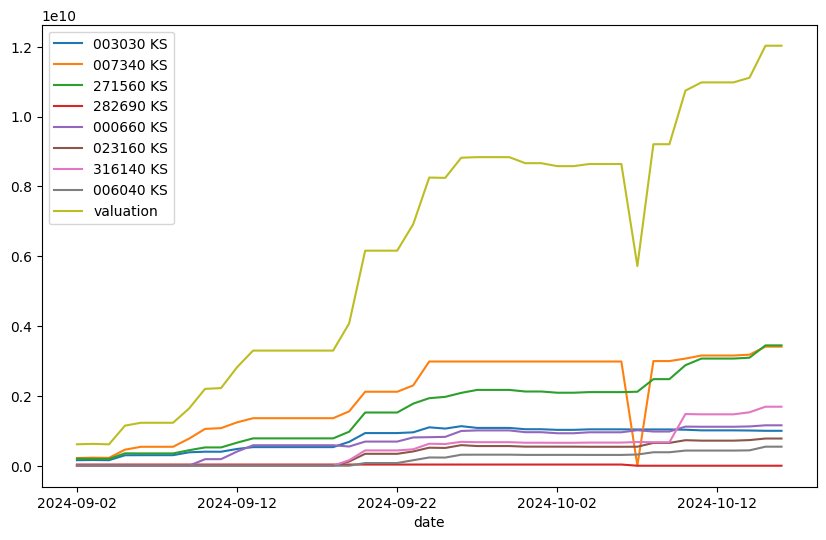

In [9]:
ts._valuations.plot(figsize=(10, 6))

In [10]:
ts._cashflow

,net_amount,realization,cash_flow
date,,,
2024-09-02,6.145814e+08,0.000000e+00,-6.145814e+08
2024-09-03,0.000000e+00,0.000000e+00,0.000000e+00
2024-09-04,0.000000e+00,0.000000e+00,0.000000e+00
2024-09-05,5.294702e+08,0.000000e+00,-5.294702e+08
2024-09-06,9.106007e+07,0.000000e+00,-9.106007e+07
2024-09-07,0.000000e+00,0.000000e+00,0.000000e+00
2024-09-08,0.000000e+00,0.000000e+00,0.000000e+00
2024-09-09,3.844826e+08,0.000000e+00,-3.844826e+08
2024-09-10,6.250762e+08,0.000000e+00,-6.250762e+08


In [11]:
ts.cash

,cash_usd,cash_krw
date,,
2024-09-01,1.578991e+07,2.112374e+10
2024-09-02,1.533070e+07,2.051784e+10
2024-09-03,1.533191e+07,2.057390e+10
2024-09-04,1.533191e+07,2.057390e+10
2024-09-05,1.493265e+07,1.992837e+10
2024-09-06,1.486473e+07,1.984442e+10
2024-09-07,1.486473e+07,1.984442e+10
2024-09-08,1.486473e+07,1.984442e+10
2024-09-09,1.457673e+07,1.945993e+10


<Axes: xlabel='date'>

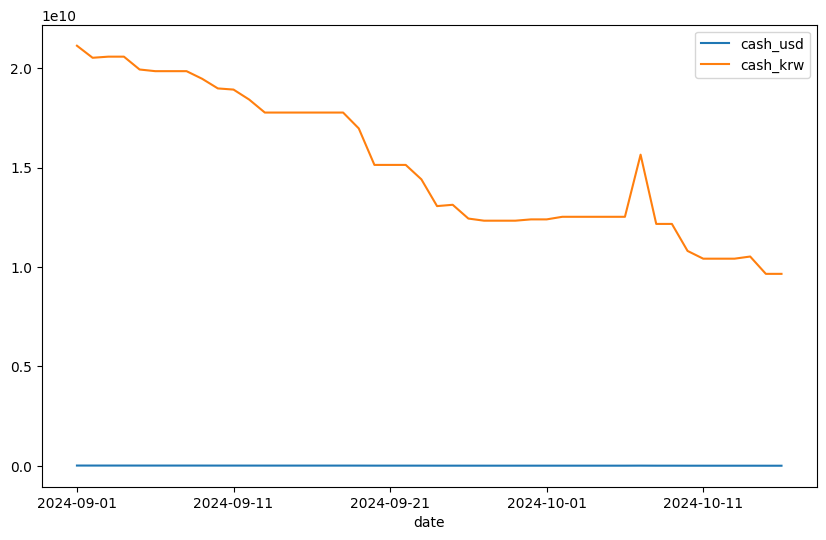

In [12]:
ts.cash.plot(figsize=(10, 6))

In [13]:
ts.stock

,stock_usd,stock_krw
date,,
2024-09-02,4.585422e+05,6.136900e+08
2024-09-03,4.666070e+05,6.261400e+08
2024-09-04,4.564722e+05,6.125400e+08
2024-09-05,8.602900e+05,1.148100e+09
2024-09-06,9.215730e+05,1.230300e+09
2024-09-07,9.215730e+05,1.230300e+09
2024-09-08,9.215730e+05,1.230300e+09
2024-09-09,1.226554e+06,1.637450e+09
2024-09-10,1.637297e+06,2.200527e+09


<Axes: xlabel='date'>

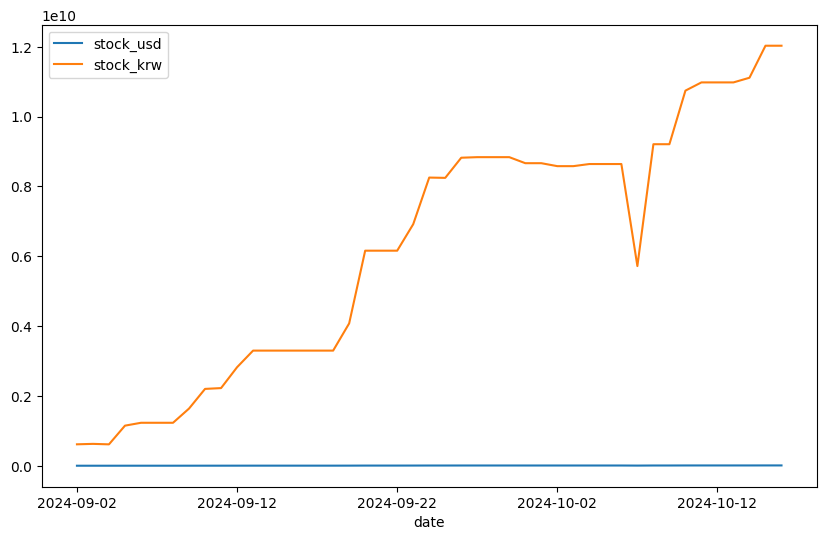

In [14]:
ts.stock.plot(figsize=(10, 6))

In [15]:
ts.df

,cash_usd,cash_krw,stock_usd,stock_krw,nav_usd,nav_krw,price_usd,price_krw,weight_cash_usd,weight_stock_krw,weight_cash_krw,weight_stock_usd,return_usd,return_krw,cumreturn_usd,cumreturn_krw
date,,,,,,,,,,,,,,,,
2024-09-01,1.578991e+07,2.112374e+10,0.000000e+00,0.000000e+00,1.578991e+07,2.112374e+10,1000.000000,1000.000000,100.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2024-09-02,1.533070e+07,2.051784e+10,4.585422e+05,6.136900e+08,1.578924e+07,2.113153e+10,999.957817,1000.368922,97.095857,2.904143,97.095857,2.904143,-0.004218,0.036892,-0.004218,0.036892
2024-09-03,1.533191e+07,2.057390e+10,4.666070e+05,6.261400e+08,1.579852e+07,2.120004e+10,1000.545512,1003.611917,97.046515,2.953485,97.046515,2.953485,0.058772,0.324180,0.054551,0.361192
2024-09-04,1.533191e+07,2.057390e+10,4.564722e+05,6.125400e+08,1.578839e+07,2.118644e+10,999.903653,1002.968091,97.108811,2.891189,97.108811,2.891189,-0.064151,-0.064151,-0.009635,0.296809
2024-09-05,1.493265e+07,1.992837e+10,8.602900e+05,1.148100e+09,1.579294e+07,2.107647e+10,1000.192115,997.762286,94.552693,5.447307,94.552693,5.447307,0.028849,-0.519040,0.019211,-0.223771
2024-09-06,1.486473e+07,1.984442e+10,9.215730e+05,1.230300e+09,1.578630e+07,2.107472e+10,999.771734,997.679223,94.162199,5.837801,94.162199,5.837801,-0.042030,-0.008325,-0.022827,-0.232078
2024-09-07,1.486473e+07,1.984442e+10,9.215730e+05,1.230300e+09,1.578630e+07,2.107472e+10,999.771734,997.679223,94.162199,5.837801,94.162199,5.837801,0.000000,0.000000,-0.022827,-0.232078
2024-09-08,1.486473e+07,1.984442e+10,9.215730e+05,1.230300e+09,1.578630e+07,2.107472e+10,999.771734,997.679223,94.162199,5.837801,94.162199,5.837801,0.000000,0.000000,-0.022827,-0.232078
2024-09-09,1.457673e+07,1.945993e+10,1.226554e+06,1.637450e+09,1.580328e+07,2.109738e+10,1000.847071,998.752309,92.238610,7.761390,92.238610,7.761390,0.107558,0.107558,0.084707,-0.124769


In [56]:
buys = trades.pl_buys[['date', 'ticker', 'delta_shares', 'net_amount', 'valuation']]
buys.columns = ['date', 'ticker', 'delta_shares', 'action', 'stock']
sells = trades.pl_sells[['date', 'ticker', 'delta_shares', 'valuation', 'realization']]
sells.columns = ['date', 'ticker', 'delta_shares', 'action', 'stock']
sells.loc[:, 'action'] = -sells['action']
sells.loc[:, 'stock'] = -sells['stock']    
df = pd.concat([buys, sells], axis=0)
df

,date,ticker,delta_shares,action,stock
0,2024-09-02,003030 KS,900,1.600410e+08,1.500300e+08
1,2024-09-02,007340 KS,2500,2.204960e+08,2.355000e+08
2,2024-09-02,271560 KS,2200,2.014920e+08,2.197800e+08
3,2024-09-02,282690 KS,2500,3.255249e+07,3.375000e+07
4,2024-09-05,003030 KS,800,1.403080e+08,1.333600e+08
...,...,...,...,...,...
71,2024-10-15,023160 KS,2500,3.554216e+07,3.540000e+07
72,2024-10-15,271560 KS,3500,3.511034e+08,3.496500e+08
73,2024-10-15,316140 KS,9500,1.577554e+08,1.574150e+08
54,2024-10-07,007340 KS,-29231,-2.816697e+09,-2.753560e+09


In [61]:
stock = df[df['ticker']=='007340 KS'].sort_values('date')
stock['action_cum'] = stock['action'].cumsum()
stock['num_shares_cum'] = stock['delta_shares'].cumsum()
stock['price_average'] = stock['action_cum'] / stock['num_shares_cum']
stock

,date,ticker,delta_shares,action,stock,action_cum,num_shares_cum,price_average
1,2024-09-02,007340 KS,2500,2.204960e+08,2.355000e+08,2.204960e+08,2500,88198.390400
5,2024-09-05,007340 KS,2500,2.293222e+08,2.355000e+08,4.498182e+08,5000,89963.633800
7,2024-09-06,007340 KS,1000,9.106007e+07,9.420000e+07,5.408782e+08,6000,90146.373000
9,2024-09-09,007340 KS,2231,2.089335e+08,2.101602e+08,7.498118e+08,8231,91096.071316
13,2024-09-10,007340 KS,3500,3.167776e+08,3.297000e+08,1.066589e+09,11731,90920.580002
15,2024-09-12,007340 KS,1500,1.391679e+08,1.413000e+08,1.205757e+09,13231,91131.226136
21,2024-09-13,007340 KS,1500,1.393188e+08,1.413000e+08,1.345076e+09,14731,91309.214106
27,2024-09-19,007340 KS,1500,1.438356e+08,1.413000e+08,1.488912e+09,16231,91732.587333
31,2024-09-20,007340 KS,4500,4.598799e+08,4.239000e+08,1.948792e+09,20731,94003.740534
41,2024-09-23,007340 KS,2000,2.016132e+08,1.884000e+08,2.150405e+09,22731,94602.294532


In [52]:
stock['delta_shares'].sum()

181000

In [50]:
19142.775044*181000

3464842282.964

In [55]:
(1357/1348-1)*100

0.667655786350152

In [42]:
holdings.list

,name,num_shares,price_average,price_last,total_amount,total_valuation,pl,return,weight,attribution
ticker,,,,,,,,,,
271560 KS,ORION CORP/REPUBLIC OF KOREA,34500,94060.807420,99900.0,3.245098e+09,3.446550e+09,201452144.0,6.207891,15.895879,0.986799
007340 KS,DN AUTOMOTIVE CORP,181000,19142.775044,18840.0,3.464842e+09,3.410040e+09,-54802283.0,-1.581667,15.727491,-0.248757
316140 KS,WOORI FINANCIAL GROUP INC,102000,16005.932882,16570.0,1.632605e+09,1.690140e+09,57534846.0,3.524113,7.795117,0.274709
000660 KS,SK HYNIX INC,6000,165217.335500,192900.0,9.913040e+08,1.157400e+09,166095987.0,16.755303,5.338060,0.894408
003030 KS,SEAH STEEL HOLDINGS CORP,5999,179830.509418,166700.0,1.078803e+09,1.000033e+09,-78769926.0,-7.301603,4.612267,-0.336769
023160 KS,TK CORPORATION,55000,14296.652200,14160.0,7.863159e+08,7.788000e+08,-7515871.0,-0.955834,3.591914,-0.034333
006040 KS,DONGWON INDUSTRIES CO LTD,16500,31811.133879,33050.0,5.248837e+08,5.453250e+08,20441291.0,3.894442,2.515101,0.097949


In [37]:
buys = trades.pl_buys[['ticker', 'delta_shares', 'net_amount', 'valuation']]
buys.columns = ['ticker', 'delta_shares', 'action', 'stock']
sells = trades.pl_sells[['ticker', 'delta_shares', 'valuation', 'realization']]
sells.columns = ['ticker', 'delta_shares', 'action', 'stock']

In [38]:
buys

,ticker,delta_shares,action,stock
0,003030 KS,900,160040981.0,150030000.0
1,007340 KS,2500,220495976.0,235500000.0
2,271560 KS,2200,201491991.0,219780000.0
3,282690 KS,2500,32552490.0,33750000.0
4,003030 KS,800,140307968.0,133360000.0
...,...,...,...,...
69,006040 KS,3150,104021367.0,104107500.0
70,007340 KS,11755,222597075.0,221464200.0
71,023160 KS,2500,35542157.0,35400000.0
72,271560 KS,3500,351103353.0,349650000.0


In [39]:
sells

,ticker,delta_shares,action,stock
54,007340 KS,-29231,2.816697e+09,2.753560e+09
55,282690 KS,-2500,3.255249e+07,3.375000e+07


In [16]:
7.751337e+06 / 7519473.57

1.0308350615028492

<Axes: xlabel='date'>

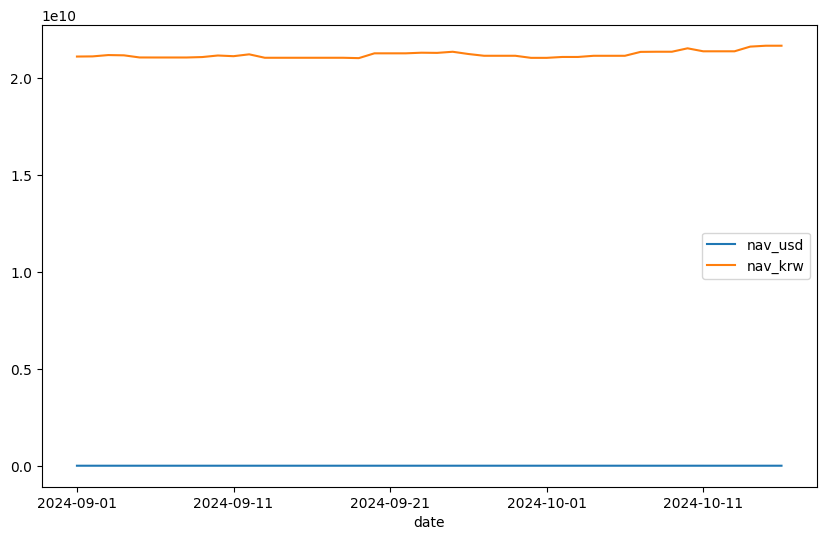

In [17]:
ts.df.filter(regex='nav').plot(figsize=(10, 6))

<Axes: xlabel='date'>

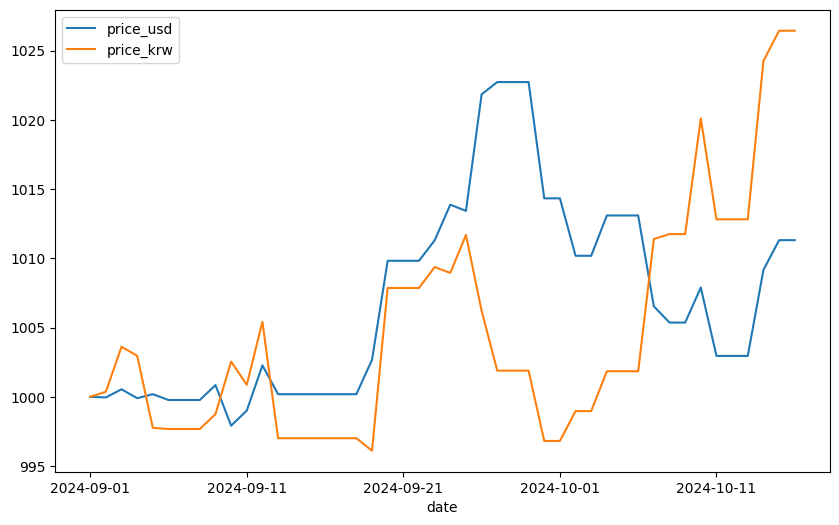

In [18]:
ts.df.filter(regex='price').plot(figsize=(10, 6))

In [19]:
holdings = Holdings(trades=trades)
holdings

In [20]:
holdings.list

,name,num_shares,price_average,price_last,total_amount,total_valuation,pl,return
ticker,,,,,,,,
271560 KS,ORION CORP/REPUBLIC OF KOREA,34500,94060.807420,99900.0,3.245098e+09,3.446550e+09,201452144.0,6.207891
007340 KS,DN AUTOMOTIVE CORP,181000,19142.775044,18840.0,3.464842e+09,3.410040e+09,-54802283.0,-1.581667
316140 KS,WOORI FINANCIAL GROUP INC,102000,16005.932882,16570.0,1.632605e+09,1.690140e+09,57534846.0,3.524113
000660 KS,SK HYNIX INC,6000,165217.335500,192900.0,9.913040e+08,1.157400e+09,166095987.0,16.755303
003030 KS,SEAH STEEL HOLDINGS CORP,5999,179830.509418,166700.0,1.078803e+09,1.000033e+09,-78769926.0,-7.301603
023160 KS,TK CORPORATION,55000,14296.652200,14160.0,7.863159e+08,7.788000e+08,-7515871.0,-0.955834
006040 KS,DONGWON INDUSTRIES CO LTD,16500,31811.133879,33050.0,5.248837e+08,5.453250e+08,20441291.0,3.894442


In [21]:
holdings.equities

2024-10-16,name_kr,name,market_index,sector,cap(/1e8),price_last
ticker_bbg,,,,,,
000660 KS Equity,SK하이닉스,SK HYNIX INC,KOSPI Index,Information Technology,1404316.0,192900.0
003030 KS Equity,세아제강지주,SEAH STEEL HOLDINGS CORP,KOSPI Index,Materials,6904.0,166700.0
006040 KS Equity,동원산업,DONGWON INDUSTRIES CO LTD,KOSPI Index,Consumer Staples,11905.0,33050.0
007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11410.0,18840.0
023160 KS Equity,태광,TK CORPORATION,KOSDAQ Index,Industrials,3752.0,14160.0
271560 KS Equity,오리온,ORION CORP/REPUBLIC OF KOREA,KOSPI Index,Consumer Staples,39496.0,99900.0
316140 KS Equity,우리금융지주,WOORI FINANCIAL GROUP INC,KOSPI Index,Financials,123047.0,16570.0


In [22]:
latest = ts.df.iloc[-1].to_dict()
latest

{'cash_usd': 7109843.7232361175,
 'cash_krw': 9653745807.41,
 'stock_usd': 8858659.817351598,
 'stock_krw': 12028288300.0,
 'nav_usd': 15968503.540587716,
 'nav_krw': 21682034107.41,
 'price_usd': 1011.3107109615771,
 'price_krw': 1026.429722935887,
 'weight_cash_usd': 44.52417037804935,
 'weight_stock_krw': 55.47582962195065,
 'weight_cash_krw': 44.52417037804935,
 'weight_stock_usd': 55.47582962195065,
 'return_usd': 0.0,
 'return_krw': 0.0,
 'cumreturn_usd': 1.1310710961577097,
 'cumreturn_krw': 2.642972293588697}

In [23]:
df = holdings.list
df['weight'] = df['total_valuation'] / latest['nav_krw'] * 100
df['attribution'] = df['weight'] * df['return'] /100
df

,name,num_shares,price_average,price_last,total_amount,total_valuation,pl,return,weight,attribution
ticker,,,,,,,,,,
271560 KS,ORION CORP/REPUBLIC OF KOREA,34500,94060.807420,99900.0,3.245098e+09,3.446550e+09,201452144.0,6.207891,15.895879,0.986799
007340 KS,DN AUTOMOTIVE CORP,181000,19142.775044,18840.0,3.464842e+09,3.410040e+09,-54802283.0,-1.581667,15.727491,-0.248757
316140 KS,WOORI FINANCIAL GROUP INC,102000,16005.932882,16570.0,1.632605e+09,1.690140e+09,57534846.0,3.524113,7.795117,0.274709
000660 KS,SK HYNIX INC,6000,165217.335500,192900.0,9.913040e+08,1.157400e+09,166095987.0,16.755303,5.338060,0.894408
003030 KS,SEAH STEEL HOLDINGS CORP,5999,179830.509418,166700.0,1.078803e+09,1.000033e+09,-78769926.0,-7.301603,4.612267,-0.336769
023160 KS,TK CORPORATION,55000,14296.652200,14160.0,7.863159e+08,7.788000e+08,-7515871.0,-0.955834,3.591914,-0.034333
006040 KS,DONGWON INDUSTRIES CO LTD,16500,31811.133879,33050.0,5.248837e+08,5.453250e+08,20441291.0,3.894442,2.515101,0.097949


In [24]:
df['weight'].sum(), df['attribution'].sum()

(55.47582962195065, 1.634006129560748)

In [34]:
history = trades.history
history = history[history['ticker']=='007340 KS']
history

,date,ticker,name,type,num_shares,price_average,net_amount,cash_flow
1,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,88110.280000,2.204960e+08,-2.204960e+08
5,2024-09-05,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,91637.240000,2.293222e+08,-2.293222e+08
7,2024-09-06,007340 KS,DN AUTOMOTIVE CORP,Buy,1000,90969.100000,9.106007e+07,-9.106007e+07
9,2024-09-09,007340 KS,DN AUTOMOTIVE CORP,Buy,2231,93556.611385,2.089335e+08,-2.089335e+08
13,2024-09-10,007340 KS,DN AUTOMOTIVE CORP,Buy,3500,90417.457143,3.167776e+08,-3.167776e+08
15,2024-09-12,007340 KS,DN AUTOMOTIVE CORP,Buy,1500,92685.933333,1.391679e+08,-1.391679e+08
21,2024-09-13,007340 KS,DN AUTOMOTIVE CORP,Buy,1500,92786.400000,1.393188e+08,-1.393188e+08
27,2024-09-19,007340 KS,DN AUTOMOTIVE CORP,Buy,1500,95794.600000,1.438356e+08,-1.438356e+08
31,2024-09-20,007340 KS,DN AUTOMOTIVE CORP,Buy,4500,102093.444444,4.598799e+08,-4.598799e+08
41,2024-09-23,007340 KS,DN AUTOMOTIVE CORP,Buy,2000,100705.900000,2.016132e+08,-2.016132e+08


In [36]:
history['cashflow'].sum()

-3297054667.0

In [24]:
trades.pl_buys

,date,ticker,name,delta_shares,price_average,price_last,net_amount,valuation,pl,return
0,2024-09-02,003030 KS,SEAH STEEL HOLDINGS CORP,900,177645.666667,166700.0,160040981.0,150030000.0,-10010981.0,-6.161516
1,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,2500,88110.280000,94200.0,220495976.0,235500000.0,15004024.0,6.911475
2,2024-09-02,271560 KS,ORION CORP/REPUBLIC OF KOREA,2200,91495.772727,99900.0,201491991.0,219780000.0,18288009.0,9.185372
3,2024-09-02,282690 KS,DONG AH TIRE & RUBBER CO LTD,2500,13007.988000,13500.0,32552490.0,33750000.0,1197510.0,3.782384
4,2024-09-05,003030 KS,SEAH STEEL HOLDINGS CORP,800,175209.750000,166700.0,140307968.0,133360000.0,-6947968.0,-4.856893
...,...,...,...,...,...,...,...,...,...,...
64,2024-10-10,271560 KS,ORION CORP/REPUBLIC OF KOREA,3200,100062.375000,99900.0,320519800.0,319680000.0,-839800.0,-0.162274
65,2024-10-10,316140 KS,WOORI FINANCIAL GROUP INC,50000,16095.446200,16570.0,805577082.0,828500000.0,22922918.0,2.948373
66,2024-10-10,007340 KS,DN AUTOMOTIVE CORP,8145,18878.147330,18840.0,153916273.0,153451800.0,-464473.0,-0.202071
67,2024-10-11,007340 KS,DN AUTOMOTIVE CORP,5000,18529.124000,18840.0,92738266.0,94200000.0,1461734.0,1.677770


In [25]:
trades.pl_sells

,date,ticker,name,delta_shares,average_purchase_price,price_last,valuation,realization,pl,return
54,2024-10-07,282690 KS,DONG AH TIRE & RUBBER CO LTD,-2500,13020.996000,13500.0,3.255249e+07,3.375000e+07,1197510.0,3.678705
55,2024-10-07,007340 KS,DN AUTOMOTIVE CORP,-29231,96359.942664,94200.0,2.816697e+09,2.753560e+09,-63137284.0,-2.241536


AttributeError: 'Trades' object has no attribute 'df'

In [17]:
buys = trades.pl_buys[['ticker', 'delta_shares', 'net_amount', 'valuation']]
buys.columns = ['ticker', 'delta_shares', 'action', 'stock']
sells = trades.pl_sells[['ticker', 'delta_shares', 'valuation', 'realization']]
sells.columns = ['ticker', 'delta_shares', 'action', 'stock']
sells['action'] = -sells['action']
sells['stock'] = -sells['stock']

/var/folders/_1/0byqfsn56tzdr_b7z00g95xw0000gn/T/ipykernel_29735/991963547.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sells['action'] = -sells['action']
/var/folders/_1/0byqfsn56tzdr_b7z00g95xw0000gn/T/ipykernel_29735/991963547.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sells['stock'] = -sells['stock']


In [18]:
buys

,ticker,delta_shares,action,stock
0,003030 KS,900,160040981.0,150030000.0
1,007340 KS,2500,220495976.0,235500000.0
2,271560 KS,2200,201491991.0,219780000.0
3,282690 KS,2500,32552490.0,33750000.0
4,003030 KS,800,140307968.0,133360000.0
...,...,...,...,...
64,271560 KS,3200,320519800.0,319680000.0
65,316140 KS,50000,805577082.0,828500000.0
66,007340 KS,8145,153916273.0,153451800.0
67,007340 KS,5000,92738266.0,94200000.0


In [19]:
sells

,ticker,delta_shares,action,stock
54,282690 KS,-2500,-3.255249e+07,-3.375000e+07
55,007340 KS,-29231,-2.816697e+09,-2.753560e+09


In [27]:
buys_sells = pd.concat([buys, sells], axis=0)
buys_sells

,ticker,delta_shares,action,stock
0,003030 KS,900,1.600410e+08,1.500300e+08
1,007340 KS,2500,2.204960e+08,2.355000e+08
2,271560 KS,2200,2.014920e+08,2.197800e+08
3,282690 KS,2500,3.255249e+07,3.375000e+07
4,003030 KS,800,1.403080e+08,1.333600e+08
...,...,...,...,...
66,007340 KS,8145,1.539163e+08,1.534518e+08
67,007340 KS,5000,9.273827e+07,9.420000e+07
68,271560 KS,2500,2.486980e+08,2.497500e+08
54,282690 KS,-2500,-3.255249e+07,-3.375000e+07


In [28]:
buys_sells.groupby('ticker').sum()

,delta_shares,action,stock
ticker,,,
000660 KS,6000,9.913040e+08,1.157400e+09
003030 KS,5999,1.078803e+09,1.000033e+09
006040 KS,13350,4.208623e+08,4.412175e+08
007340 KS,169245,3.242245e+09,3.188576e+09
023160 KS,52500,7.507737e+08,7.434000e+08
271560 KS,31000,2.893995e+09,3.096900e+09
282690 KS,0,3.725290e-09,0.000000e+00
316140 KS,92500,1.474850e+09,1.532725e+09


In [72]:
df = pd.concat([buys, sells]).groupby(['ticker']).sum()
df = df[df['delta_shares'] != 0]
df['price_average'] = df['action'] / df['delta_shares']
df['price_last'] = df['stock'] / df['delta_shares']
df['ticker_bbg'] = df.index.map(get_ticker_bbg_of_ticker)
df['name'] = df['ticker_bbg'].map(get_mapping_ks_name())
cols_to_keep = ['name', 'delta_shares', 'price_average', 'price_last', 'action', 'stock']
df = df[cols_to_keep]
df['pl'] = df['stock'] - df['action']
df['return'] = df['pl'] / df['action'] * 100
df = df.rename(columns={'delta_shares': 'num_shares', 'action': 'total_amount', 'stock': 'total_valuation'})
df = df.sort_values('total_valuation', ascending=False)
df

,name,num_shares,price_average,price_last,total_amount,total_valuation,pl,return
ticker,,,,,,,,
007340 KS,DN AUTOMOTIVE CORP,169245,19157.110745,18840.0,3.242245e+09,3.188576e+09,-53669408.0,-1.655316
271560 KS,ORION CORP/REPUBLIC OF KOREA,31000,93354.661387,99900.0,2.893995e+09,3.096900e+09,202905497.0,7.011261
316140 KS,WOORI FINANCIAL GROUP INC,92500,15944.321254,16570.0,1.474850e+09,1.532725e+09,57875284.0,3.924148
000660 KS,SK HYNIX INC,6000,165217.335500,192900.0,9.913040e+08,1.157400e+09,166095987.0,16.755303
003030 KS,SEAH STEEL HOLDINGS CORP,5999,179830.509418,166700.0,1.078803e+09,1.000033e+09,-78769926.0,-7.301603
023160 KS,TK CORPORATION,52500,14300.451695,14160.0,7.507737e+08,7.434000e+08,-7373714.0,-0.982149
006040 KS,DONGWON INDUSTRIES CO LTD,13350,31525.269064,33050.0,4.208623e+08,4.412175e+08,20355158.0,4.836536


In [57]:
ks_price = get_ks_market_info()[['price_last']]
ks_price

,price_last
ticker_bbg,
000020 KS Equity,7910.0
000040 KS Equity,509.0
000050 KS Equity,6190.0
000070 KS Equity,78200.0
000080 KS Equity,20250.0
...,...
950170 KS Equity,4205.0
950190 KS Equity,10870.0
950200 KS Equity,4600.0


In [58]:
df_holdings = df.merge(ks_price, how='left', left_on='ticker_bbg', right_index=True)
df_holdings['valuation'] = df_holdings['delta_shares'] * df_holdings['price_last']

,delta_shares,action,stock,price_average,ticker_bbg,price_last
ticker,,,,,,
000660 KS,6000,9.913040e+08,1.157400e+09,165217.335500,000660 KS Equity,192900.0
003030 KS,5999,1.078803e+09,1.000033e+09,179830.509418,003030 KS Equity,166700.0
006040 KS,13350,4.208623e+08,4.412175e+08,31525.269064,006040 KS Equity,33050.0
007340 KS,169245,3.242245e+09,3.188576e+09,19157.110745,007340 KS Equity,18840.0
023160 KS,52500,7.507737e+08,7.434000e+08,14300.451695,023160 KS Equity,14160.0
271560 KS,31000,2.893995e+09,3.096900e+09,93354.661387,271560 KS Equity,99900.0
316140 KS,92500,1.474850e+09,1.532725e+09,15944.321254,316140 KS Equity,16570.0


,name_kr,name,market_index,sector,cap(/1e8),price_last
ticker_bbg,,,,,,
000020 KS Equity,동화약품,DONGWHA PHARM CO LTD,KOSPI Index,Health Care,2209.0,7910.0
000040 KS Equity,KR모터스,KR MOTORS CO LTD,KOSPI Index,Consumer Discretionary,306.0,509.0
000050 KS Equity,경방,KYUNGBANG CO LTD,KOSPI Index,Consumer Discretionary,1697.0,6190.0
000070 KS Equity,삼양홀딩스,SAMYANG HOLDINGS CORP,KOSPI Index,Consumer Staples,6697.0,78200.0
000080 KS Equity,하이트진로,HITE JINRO CO LTD,KOSPI Index,Consumer Staples,14202.0,20250.0
...,...,...,...,...,...,...
950170 KS Equity,JTC,NaN,NaN,NaN,2114.0,4205.0
950190 KS Equity,미투젠,NaN,NaN,NaN,1476.0,10870.0
950200 KS Equity,소마젠,NaN,NaN,NaN,884.0,4600.0


,delta_shares,action,stock,price_average,pl
ticker,,,,,
000660 KS,6000,9.913040e+08,1.157400e+09,1.652173e+05,1.660960e+08
003030 KS,5999,1.078803e+09,1.000033e+09,1.798305e+05,-7.876993e+07
006040 KS,13350,4.208623e+08,4.412175e+08,3.152527e+04,2.035516e+07
007340 KS,169245,3.242245e+09,3.188576e+09,1.915711e+04,-5.366941e+07
023160 KS,52500,7.507737e+08,7.434000e+08,1.430045e+04,-7.373714e+06
271560 KS,31000,2.893995e+09,3.096900e+09,9.335466e+04,2.029055e+08
282690 KS,0,3.725290e-09,0.000000e+00,inf,-3.725290e-09
316140 KS,92500,1.474850e+09,1.532725e+09,1.594432e+04,5.787528e+07


In [22]:
buys = trades.pl_buys[['date', 'ticker', 'delta_shares', 'net_amount', 'valuation']]
buys

,date,ticker,delta_shares,net_amount,valuation
0,2024-09-02,003030 KS,900,160040981.0,150030000.0
1,2024-09-02,007340 KS,2500,220495976.0,235500000.0
2,2024-09-02,271560 KS,2200,201491991.0,219780000.0
3,2024-09-02,282690 KS,2500,32552490.0,33750000.0
4,2024-09-05,003030 KS,800,140307968.0,133360000.0
...,...,...,...,...,...
64,2024-10-10,271560 KS,3200,320519800.0,319680000.0
65,2024-10-10,316140 KS,50000,805577082.0,828500000.0
66,2024-10-10,007340 KS,8145,153916273.0,153451800.0
67,2024-10-11,007340 KS,5000,92738266.0,94200000.0


In [ ]:
sells = trades.pl_sells[['date', 'ticker', 'delta_shares', 'net_amount', 'realization']]
sells

In [8]:
trades.history

,date,ticker,name,type,num_shares,price_average,net_amount,cash_flow
0,2024-09-02,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,900,177645.666667,160040981.0,-160040981.0
1,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,88110.280000,220495976.0,-220495976.0
2,2024-09-02,271560 KS,ORION CORP/REPUBLIC OF KOREA,Buy,2200,91495.772727,201491991.0,-201491991.0
3,2024-09-02,282690 KS,DONG AH TIRE & RUBBER CO LTD,Buy,2500,13007.988000,32552490.0,-32552490.0
4,2024-09-05,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,800,175209.750000,140307968.0,-140307968.0
...,...,...,...,...,...,...,...,...
64,2024-10-10,271560 KS,ORION CORP/REPUBLIC OF KOREA,Buy,3200,100062.375000,320519800.0,-320519800.0
65,2024-10-10,316140 KS,WOORI FINANCIAL GROUP INC,Buy,50000,16095.446200,805577082.0,-805577082.0
66,2024-10-10,007340 KS,DN AUTOMOTIVE CORP,Buy,8145,18878.147330,153916273.0,-153916273.0
67,2024-10-11,007340 KS,DN AUTOMOTIVE CORP,Buy,5000,18529.124000,92738266.0,-92738266.0


In [12]:
ts._valuations

{'003030 KS':                003030 KS
 date                    
 2024-09-02  1.585800e+08
 2024-09-03  1.638000e+08
 2024-09-04  1.584000e+08
 2024-09-05  3.000500e+08
 2024-09-06  3.017500e+08
 2024-09-07  3.017500e+08
 2024-09-08  3.017500e+08
 2024-09-09  3.843400e+08
 2024-09-10  4.017600e+08
 2024-09-11  4.005600e+08
 2024-09-12  4.801500e+08
 2024-09-13  5.328900e+08
 2024-09-14  5.328900e+08
 2024-09-15  5.328900e+08
 2024-09-16  5.328900e+08
 2024-09-17  5.328900e+08
 2024-09-18  5.328900e+08
 2024-09-19  6.838200e+08
 2024-09-20  9.348130e+08
 2024-09-21  9.348130e+08
 2024-09-22  9.348130e+08
 2024-09-23  9.563678e+08
 2024-09-24  1.099784e+09
 2024-09-25  1.063565e+09
 2024-09-26  1.132611e+09
 2024-09-27  1.082820e+09
 2024-09-28  1.082820e+09
 2024-09-29  1.082820e+09
 2024-09-30  1.045026e+09
 2024-10-01  1.045026e+09
 2024-10-02  1.027029e+09
 2024-10-03  1.027029e+09
 2024-10-04  1.042026e+09
 2024-10-05  1.042026e+09
 2024-10-06  1.042026e+09
 2024-10-07  1.037827e+09

In [14]:
dct = ts._valuations

dfs = list(dct.values())
# df = pd.concat(dfs, axis=1, join='outer')
df = pd.concat(dfs, axis=1).fillna(0)
df['valuation'] = df.sum(axis=1)
df

,003030 KS,007340 KS,271560 KS,282690 KS,000660 KS,023160 KS,316140 KS,006040 KS,valuation
date,,,,,,,,,
2024-09-02,1.585800e+08,2.205000e+08,2.008600e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0,6.136900e+08
2024-09-03,1.638000e+08,2.312500e+08,1.973400e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0,6.261400e+08
2024-09-04,1.584000e+08,2.252500e+08,1.951400e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0,6.125400e+08
2024-09-05,3.000500e+08,4.595000e+08,3.548000e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0,1.148100e+09
2024-09-06,3.017500e+08,5.424000e+08,3.524000e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0,1.230300e+09
2024-09-07,3.017500e+08,5.424000e+08,3.524000e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0,1.230300e+09
2024-09-08,3.017500e+08,5.424000e+08,3.524000e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0,1.230300e+09
2024-09-09,3.843400e+08,7.753602e+08,4.440000e+08,33750000.0,0.000000e+00,0.0,0.000000e+00,0.0,1.637450e+09
2024-09-10,4.017600e+08,1.054617e+09,5.238000e+08,33750000.0,1.866000e+08,0.0,0.000000e+00,0.0,2.200527e+09


In [3]:
ts = Timeseries(trades)

In [4]:
ts.cash

,cash_usd,cash_krw
date,,
2024-09-01,1.578991e+07,2.112374e+10
2024-09-02,1.533070e+07,2.051784e+10
2024-09-03,1.533191e+07,2.057390e+10
2024-09-04,1.533191e+07,2.057390e+10
2024-09-05,1.493265e+07,1.992837e+10
2024-09-06,1.486473e+07,1.984442e+10
2024-09-07,1.486473e+07,1.984442e+10
2024-09-08,1.486473e+07,1.984442e+10
2024-09-09,1.457673e+07,1.945993e+10


In [5]:
ts.stock

,stock_usd,stock_krw
date,,
2024-09-02,4.585422e+05,6.136900e+08
2024-09-03,4.666070e+05,6.261400e+08
2024-09-04,4.564722e+05,6.125400e+08
2024-09-05,8.602900e+05,1.148100e+09
2024-09-06,9.215730e+05,1.230300e+09
2024-09-07,9.215730e+05,1.230300e+09
2024-09-08,9.215730e+05,1.230300e+09
2024-09-09,1.226554e+06,1.637450e+09
2024-09-10,1.637297e+06,2.200527e+09


In [6]:
ts.df

,cash_usd,cash_krw,stock_usd,stock_krw,nav_usd,nav_krw,price_usd,price_krw,weight_cash_usd,weight_stock_krw,weight_stock_usd,weight_cash_krw,return_usd,return_krw,cumreturn_usd,cumreturn_krw
date,,,,,,,,,,,,,,,,
2024-09-01,1.578991e+07,2.112374e+10,0.000000e+00,0.000000e+00,1.578991e+07,2.112374e+10,1000.000000,1000.000000,100.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000
2024-09-02,1.533070e+07,2.051784e+10,4.585422e+05,6.136900e+08,1.578924e+07,2.113153e+10,999.957817,1000.368922,97.095857,2.904143,2.904143,97.095857,-0.004218,0.036892,-0.004218,0.036892
2024-09-03,1.533191e+07,2.057390e+10,4.666070e+05,6.261400e+08,1.579852e+07,2.120004e+10,1000.545512,1003.611917,97.046515,2.953485,2.953485,97.046515,0.058772,0.324180,0.054551,0.361192
2024-09-04,1.533191e+07,2.057390e+10,4.564722e+05,6.125400e+08,1.578839e+07,2.118644e+10,999.903653,1002.968091,97.108811,2.891189,2.891189,97.108811,-0.064151,-0.064151,-0.009635,0.296809
2024-09-05,1.493265e+07,1.992837e+10,8.602900e+05,1.148100e+09,1.579294e+07,2.107647e+10,1000.192115,997.762286,94.552693,5.447307,5.447307,94.552693,0.028849,-0.519040,0.019211,-0.223771
2024-09-06,1.486473e+07,1.984442e+10,9.215730e+05,1.230300e+09,1.578630e+07,2.107472e+10,999.771734,997.679223,94.162199,5.837801,5.837801,94.162199,-0.042030,-0.008325,-0.022827,-0.232078
2024-09-07,1.486473e+07,1.984442e+10,9.215730e+05,1.230300e+09,1.578630e+07,2.107472e+10,999.771734,997.679223,94.162199,5.837801,5.837801,94.162199,0.000000,0.000000,-0.022827,-0.232078
2024-09-08,1.486473e+07,1.984442e+10,9.215730e+05,1.230300e+09,1.578630e+07,2.107472e+10,999.771734,997.679223,94.162199,5.837801,5.837801,94.162199,0.000000,0.000000,-0.022827,-0.232078
2024-09-09,1.457673e+07,1.945993e+10,1.226554e+06,1.637450e+09,1.580328e+07,2.109738e+10,1000.847071,998.752309,92.238610,7.761390,7.761390,92.238610,0.107558,0.107558,0.084707,-0.124769


In [22]:
latest = ts.df.iloc[-1].to_dict()
latest

{'cash_usd': 7751336.866556194,
 'cash_krw': 10524765197.41,
 'stock_usd': 8219363.381941376,
 'stock_krw': 11160251600.0,
 'nav_usd': 15970700.24849757,
 'nav_krw': 21685016797.41,
 'price_usd': 1011.449831965148,
 'price_krw': 1026.570923787022,
 'weight_cash_usd': 48.534733893621194,
 'weight_stock_krw': 51.465266106378806,
 'weight_stock_usd': 51.465266106378806,
 'weight_cash_krw': 48.534733893621194,
 'return_usd': 0.0,
 'return_krw': 0.0,
 'cumreturn_usd': 1.1449831965147927,
 'cumreturn_krw': 2.657092378702197}

In [24]:
df = holdings.df
df

AttributeError: module 'cayman_office_system.holdings' has no attribute 'df'

In [16]:
df = ts.cash.merge(ts.stock, how='left', left_index=True, right_index=True).fillna(0)
df['nav_usd'] = df['cash_usd'] + df['stock_usd']
df['nav_krw'] = df['cash_krw'] + df['stock_krw']
df['price_usd'] = df['nav_usd']/df['nav_usd'].iloc[0]*1000
df['price_krw'] = df['nav_krw']/df['nav_krw'].iloc[0]*1000
df

,cash_usd,cash_krw,stock_usd,stock_krw,nav_usd,nav_krw,price_usd,price_krw
date,,,,,,,,
2024-09-01,1.578991e+07,2.112374e+10,0.000000e+00,0.000000e+00,1.578991e+07,2.112374e+10,1000.000000,1000.000000
2024-09-02,1.533070e+07,2.051784e+10,4.585422e+05,6.136900e+08,1.578924e+07,2.113153e+10,999.957817,1000.368922
2024-09-03,1.533191e+07,2.057390e+10,4.666070e+05,6.261400e+08,1.579852e+07,2.120004e+10,1000.545512,1003.611917
2024-09-04,1.533191e+07,2.057390e+10,4.564722e+05,6.125400e+08,1.578839e+07,2.118644e+10,999.903653,1002.968091
2024-09-05,1.493265e+07,1.992837e+10,8.602900e+05,1.148100e+09,1.579294e+07,2.107647e+10,1000.192115,997.762286
2024-09-06,1.486473e+07,1.984442e+10,9.215730e+05,1.230300e+09,1.578630e+07,2.107472e+10,999.771734,997.679223
2024-09-07,1.486473e+07,1.984442e+10,9.215730e+05,1.230300e+09,1.578630e+07,2.107472e+10,999.771734,997.679223
2024-09-08,1.486473e+07,1.984442e+10,9.215730e+05,1.230300e+09,1.578630e+07,2.107472e+10,999.771734,997.679223
2024-09-09,1.457673e+07,1.945993e+10,1.226554e+06,1.637450e+09,1.580328e+07,2.109738e+10,1000.847071,998.752309


In [7]:
(9425919/9368547.11-1)*100

0.6123883386225604

<Axes: xlabel='date'>

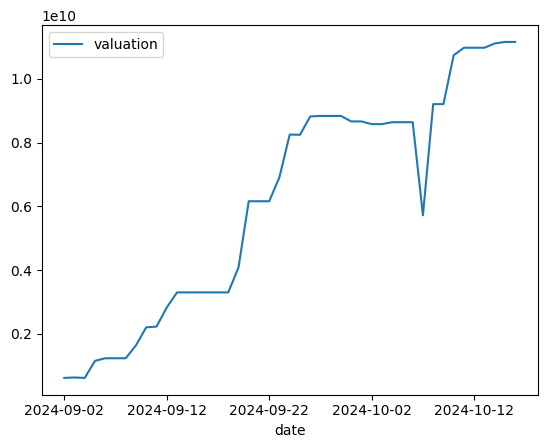

In [4]:
ts.valuation.plot()

In [6]:
ts.cashflow

,cash_flow
date,
2024-09-02,-6.145814e+08
2024-09-03,0.000000e+00
2024-09-04,0.000000e+00
2024-09-05,-5.294702e+08
2024-09-06,-9.106007e+07
2024-09-07,0.000000e+00
2024-09-08,0.000000e+00
2024-09-09,-3.844826e+08
2024-09-10,-6.250762e+08


In [16]:
frame = ts.frame
frame['usdkrw'] = frame.index.map(get_usdkrw_of_date)
frame['initial_balance_usd'] = frame['initial_balance_usd'].ffill()
frame['initial_balance_krw'] = frame['initial_balance_usd'] * frame['usdkrw']
frame = frame.merge(ts.cashflow, left_index=True, right_index=True, how='left')
frame['cashflow'] = frame['cashflow'].fillna(0)
frame['cashflow_cum'] = frame['cashflow'].cumsum()
frame['cash_krw'] = frame['initial_balance_krw'] + frame['cashflow_cum']
frame['cash_usd'] = frame['cash_krw'] / frame['usdkrw']
cols_to_keep = ['cash_usd', 'cash_krw']
frame = frame[cols_to_keep]
frame


,cash_usd,cash_krw
date,,
2024-09-01,1.533081e+07,2.050955e+10
2024-09-02,1.487160e+07,1.990340e+10
2024-09-03,1.487281e+07,1.995783e+10
2024-09-04,1.487281e+07,1.995783e+10
2024-09-05,1.447355e+07,1.931568e+10
2024-09-06,1.440563e+07,1.923151e+10
2024-09-07,1.440563e+07,1.923151e+10
2024-09-08,1.440563e+07,1.923151e+10
2024-09-09,1.411763e+07,1.884703e+10


In [4]:
dfs = list(ts._valuations.values())
dfs

[               003030 KS
 date                    
 2024-09-02  1.585800e+08
 2024-09-03  1.638000e+08
 2024-09-04  1.584000e+08
 2024-09-05  3.000500e+08
 2024-09-06  3.017500e+08
 2024-09-07  3.017500e+08
 2024-09-08  3.017500e+08
 2024-09-09  3.843400e+08
 2024-09-10  4.017600e+08
 2024-09-11  4.005600e+08
 2024-09-12  4.801500e+08
 2024-09-13  5.328900e+08
 2024-09-14  5.328900e+08
 2024-09-15  5.328900e+08
 2024-09-16  5.328900e+08
 2024-09-17  5.328900e+08
 2024-09-18  5.328900e+08
 2024-09-19  6.838200e+08
 2024-09-20  9.348130e+08
 2024-09-21  9.348130e+08
 2024-09-22  9.348130e+08
 2024-09-23  9.563678e+08
 2024-09-24  1.099784e+09
 2024-09-25  1.063565e+09
 2024-09-26  1.132611e+09
 2024-09-27  1.082820e+09
 2024-09-28  1.082820e+09
 2024-09-29  1.082820e+09
 2024-09-30  1.045026e+09
 2024-10-01  1.045026e+09
 2024-10-02  1.027029e+09
 2024-10-03  1.027029e+09
 2024-10-04  1.042026e+09
 2024-10-05  1.042026e+09
 2024-10-06  1.042026e+09
 2024-10-07  1.037827e+09
 2024-10-08 

In [5]:
pd.concat(dfs, axis=1)

,003030 KS,007340 KS,271560 KS,282690 KS,000660 KS,023160 KS,316140 KS,006040 KS
date,,,,,,,,
2024-09-02,1.585800e+08,2.205000e+08,2.008600e+08,33750000.0,NaN,NaN,NaN,NaN
2024-09-03,1.638000e+08,2.312500e+08,1.973400e+08,33750000.0,NaN,NaN,NaN,NaN
2024-09-04,1.584000e+08,2.252500e+08,1.951400e+08,33750000.0,NaN,NaN,NaN,NaN
2024-09-05,3.000500e+08,4.595000e+08,3.548000e+08,33750000.0,NaN,NaN,NaN,NaN
2024-09-06,3.017500e+08,5.424000e+08,3.524000e+08,33750000.0,NaN,NaN,NaN,NaN
2024-09-07,3.017500e+08,5.424000e+08,3.524000e+08,33750000.0,NaN,NaN,NaN,NaN
2024-09-08,3.017500e+08,5.424000e+08,3.524000e+08,33750000.0,NaN,NaN,NaN,NaN
2024-09-09,3.843400e+08,7.753602e+08,4.440000e+08,33750000.0,NaN,NaN,NaN,NaN
2024-09-10,4.017600e+08,1.054617e+09,5.238000e+08,33750000.0,1.866000e+08,NaN,NaN,NaN


In [4]:
ts.frame

,initial_balance_usd
date,
2024-09-01,15330806.5


In [6]:
ts.cash

,cash_flow
date,
2024-09-02,-6.145814e+08
2024-09-03,0.000000e+00
2024-09-04,0.000000e+00
2024-09-05,-5.294702e+08
2024-09-06,-9.106007e+07
2024-09-07,0.000000e+00
2024-09-08,0.000000e+00
2024-09-09,-3.844826e+08
2024-09-10,-6.250762e+08


In [9]:
ts.valuation.index[:20]

Index(['2024-09-02', '2024-09-03', '2024-09-04', '2024-09-05', '2024-09-06',
       '2024-09-07', '2024-09-08', '2024-09-09', '2024-09-10', '2024-09-11',
       '2024-09-12', '2024-09-13', '2024-09-14', '2024-09-15', '2024-09-16',
       '2024-09-17', '2024-09-18', '2024-09-19', '2024-09-20', '2024-09-21'],
      dtype='object', name='date')

In [3]:
trades.history

,date,ticker,name,type,num_shares,price_average,net_amount,cash_flow
0,2024-09-02,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,900,177645.666667,160040981.0,-160040981.0
1,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,88110.280000,220495976.0,-220495976.0
2,2024-09-02,271560 KS,ORION CORP/REPUBLIC OF KOREA,Buy,2200,91495.772727,201491991.0,-201491991.0
3,2024-09-02,282690 KS,DONG AH TIRE & RUBBER CO LTD,Buy,2500,13007.988000,32552490.0,-32552490.0
4,2024-09-05,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,800,175209.750000,140307968.0,-140307968.0
...,...,...,...,...,...,...,...,...
64,2024-10-10,271560 KS,ORION CORP/REPUBLIC OF KOREA,Buy,3200,100062.375000,320519800.0,-320519800.0
65,2024-10-10,316140 KS,WOORI FINANCIAL GROUP INC,Buy,50000,16095.446200,805577082.0,-805577082.0
66,2024-10-10,007340 KS,DN AUTOMOTIVE CORP,Buy,8145,18878.147330,153916273.0,-153916273.0
67,2024-10-11,007340 KS,DN AUTOMOTIVE CORP,Buy,5000,18529.124000,92738266.0,-92738266.0


In [ ]:
ts = Timeseries(trades=trades)

In [5]:
ts.frame

,initial_balance_usd
date,
2024-09-01,15330806.5


In [4]:
trades.timeseries_valuation

,valuation
date,
2024-09-02,158580000.0
2024-09-03,163800000.0
2024-09-04,158400000.0
2024-09-05,300050000.0
2024-09-06,301750000.0
...,...
2024-10-11,433875000.0
2024-10-12,433875000.0
2024-10-13,433875000.0


In [5]:
trades.timeseries_cash

,cash_flow
date,
2024-09-02,-6.145814e+08
2024-09-03,0.000000e+00
2024-09-04,0.000000e+00
2024-09-05,-5.294702e+08
2024-09-06,-9.106007e+07
2024-09-07,0.000000e+00
2024-09-08,0.000000e+00
2024-09-09,-3.844826e+08
2024-09-10,-6.250762e+08


In [26]:
buys = trades.pl_buys[['date', 'net_amount']]
buys

,date,net_amount
0,2024-09-02,160040981.0
1,2024-09-02,220495976.0
2,2024-09-02,201491991.0
3,2024-09-02,32552490.0
4,2024-09-05,140307968.0
...,...,...
64,2024-10-10,320519800.0
65,2024-10-10,805577082.0
66,2024-10-10,153916273.0
67,2024-10-11,92738266.0


In [27]:
sells = trades.pl_sells[['date', 'realization']]
sells

,date,realization
54,2024-10-07,3.375000e+07
55,2024-10-07,2.753560e+09


In [30]:
cash = pd.concat([buys, sells]).sort_values('date').fillna(0).groupby('date').sum()
cash['cashflow'] = -cash['net_amount'] + cash['realization']
cash['cash'] = cash['cashflow'].cumsum()
cash

,net_amount,realization,cash_flow,cash
date,,,,
2024-09-02,6.145814e+08,0.000000e+00,-6.145814e+08,-6.145814e+08
2024-09-05,5.294702e+08,0.000000e+00,-5.294702e+08,-1.144052e+09
2024-09-06,9.106007e+07,0.000000e+00,-9.106007e+07,-1.235112e+09
2024-09-09,3.844826e+08,0.000000e+00,-3.844826e+08,-1.619594e+09
2024-09-10,6.250762e+08,0.000000e+00,-6.250762e+08,-2.244670e+09
2024-09-12,5.286863e+08,0.000000e+00,-5.286863e+08,-2.773357e+09
2024-09-13,5.196912e+08,0.000000e+00,-5.196912e+08,-3.293048e+09
2024-09-19,7.272345e+08,0.000000e+00,-7.272345e+08,-4.020282e+09
2024-09-20,1.931465e+09,0.000000e+00,-1.931465e+09,-5.951748e+09


<Axes: xlabel='date'>

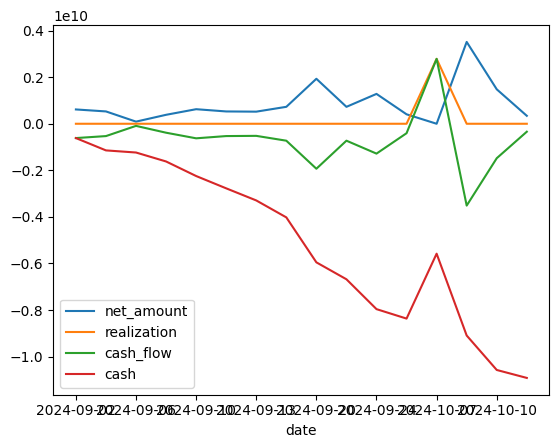

In [31]:
cash.plot()

In [8]:
trades.timeseries_valuation

,003030 KS,007340 KS,271560 KS,282690 KS,000660 KS,023160 KS,316140 KS,006040 KS,valuation
date,,,,,,,,,
2024-09-02,1.585800e+08,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,1.585800e+08
2024-09-03,1.638000e+08,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,1.638000e+08
2024-09-04,1.584000e+08,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,1.584000e+08
2024-09-05,3.000500e+08,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,3.000500e+08
2024-09-06,3.017500e+08,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,3.017500e+08
...,...,...,...,...,...,...,...,...,...
2024-10-08,1.000033e+09,3.188576e+09,3.096900e+09,0.0,1.157400e+09,743400000.0,1.532725e+09,385800000.0,1.110483e+10
2024-10-10,1.000033e+09,3.188576e+09,3.096900e+09,0.0,1.157400e+09,743400000.0,1.532725e+09,433875000.0,1.115291e+10
2024-10-11,1.000033e+09,3.188576e+09,3.096900e+09,0.0,1.157400e+09,743400000.0,1.532725e+09,433875000.0,1.115291e+10


In [8]:
trades.pl_buys

,date,ticker,name,delta_shares,price_average,price_last,net_amount,valuation,pl,return
0,2024-09-02,003030 KS,SEAH STEEL HOLDINGS CORP,900,177645.666667,166700.0,160040981.0,150030000.0,-10010981.0,-6.161516
1,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,2500,88110.280000,94200.0,220495976.0,235500000.0,15004024.0,6.911475
2,2024-09-02,271560 KS,ORION CORP/REPUBLIC OF KOREA,2200,91495.772727,99900.0,201491991.0,219780000.0,18288009.0,9.185372
3,2024-09-02,282690 KS,DONG AH TIRE & RUBBER CO LTD,2500,13007.988000,13500.0,32552490.0,33750000.0,1197510.0,3.782384
4,2024-09-05,003030 KS,SEAH STEEL HOLDINGS CORP,800,175209.750000,166700.0,140307968.0,133360000.0,-6947968.0,-4.856893
...,...,...,...,...,...,...,...,...,...,...
64,2024-10-10,271560 KS,ORION CORP/REPUBLIC OF KOREA,3200,100062.375000,99900.0,320519800.0,319680000.0,-839800.0,-0.162274
65,2024-10-10,316140 KS,WOORI FINANCIAL GROUP INC,50000,16095.446200,16570.0,805577082.0,828500000.0,22922918.0,2.948373
66,2024-10-10,007340 KS,DN AUTOMOTIVE CORP,8145,18878.147330,18840.0,153916273.0,153451800.0,-464473.0,-0.202071
67,2024-10-11,007340 KS,DN AUTOMOTIVE CORP,5000,18529.124000,18840.0,92738266.0,94200000.0,1461734.0,1.677770


In [4]:
merged_info = trades.merged_info
merged_info

,date,name_x,ticker,type,num_shares,price_average,consideration,commission,net_amount,delta_shares,cash_flow,ticker_bbg,name_kr,name,market_index,sector,cap(/1e8),price_last
0,2024-09-02,SeAH Steel Holdings,003030 KS,Buy,900,177645.666667,159881100.0,159881.0,160040981.0,900,-160040981.0,003030 KS Equity,세아제강지주,SEAH STEEL HOLDINGS CORP,KOSPI Index,Materials,6904.0,166700.0
1,2024-09-02,DN AUTOMOTIVE,007340 KS,Buy,2500,88110.280000,220275700.0,220276.0,220495976.0,2500,-220495976.0,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11410.0,18840.0
2,2024-09-02,ORION,271560 KS,Buy,2200,91495.772727,201290700.0,201291.0,201491991.0,2200,-201491991.0,271560 KS Equity,오리온,ORION CORP/REPUBLIC OF KOREA,KOSPI Index,Consumer Staples,39496.0,99900.0
3,2024-09-02,DONG AH TIRE,282690 KS,Buy,2500,13007.988000,32519970.0,32520.0,32552490.0,2500,-32552490.0,282690 KS Equity,동아타이어,DONG AH TIRE & RUBBER CO LTD,KOSPI Index,Consumer Discretionary,1853.0,13500.0
4,2024-09-05,SeAH Steel Holdings,003030 KS,Buy,800,175209.750000,140167800.0,140168.0,140307968.0,800,-140307968.0,003030 KS Equity,세아제강지주,SEAH STEEL HOLDINGS CORP,KOSPI Index,Materials,6904.0,166700.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,2024-10-10,ORION,271560 KS,Buy,3200,100062.375000,320199600.0,320200.0,320519800.0,3200,-320519800.0,271560 KS Equity,오리온,ORION CORP/REPUBLIC OF KOREA,KOSPI Index,Consumer Staples,39496.0,99900.0
65,2024-10-10,WooriFinancialGroup,316140 KS,Buy,50000,16095.446200,804772310.0,804772.0,805577082.0,50000,-805577082.0,316140 KS Equity,우리금융지주,WOORI FINANCIAL GROUP INC,KOSPI Index,Financials,123047.0,16570.0
66,2024-10-10,DN AUTOMOTIVE,007340 KS,Buy,8145,18878.147330,153762510.0,153763.0,153916273.0,8145,-153916273.0,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11410.0,18840.0
67,2024-10-11,DN AUTOMOTIVE,007340 KS,Buy,5000,18529.124000,92645620.0,92646.0,92738266.0,5000,-92738266.0,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11410.0,18840.0


In [6]:
df_nums = merged_info[['date', 'ticker', 'delta_shares']]
df_nums

,date,ticker,delta_shares
0,2024-09-02,003030 KS,900
1,2024-09-02,007340 KS,2500
2,2024-09-02,271560 KS,2200
3,2024-09-02,282690 KS,2500
4,2024-09-05,003030 KS,800
...,...,...,...
64,2024-10-10,271560 KS,3200
65,2024-10-10,316140 KS,50000
66,2024-10-10,007340 KS,8145
67,2024-10-11,007340 KS,5000


In [105]:
dct = {}
for ticker in df_nums['ticker'].unique():
    df = df_nums[df_nums['ticker'] == ticker].copy()
    df[f'num_shares: {ticker}'] = df['delta_shares'].cumsum()
    df = df.set_index('date')
    price = get_price_by_ticker(ticker)
    price = price[price.index>=df.index[0]]
    df = df.merge(price, how='right', left_index=True, right_index=True)
    df[f'num_shares: {ticker}'] = df[f'num_shares: {ticker}'].ffill().fillna(0)
    df[ticker] = df[f'num_shares: {ticker}'] * df['price_last']
    cols_to_keep = [ticker]
    df = df[cols_to_keep]
    dct[ticker] = df
dct

{'003030 KS':                003030 KS
 date                    
 2024-09-02  1.585800e+08
 2024-09-03  1.638000e+08
 2024-09-04  1.584000e+08
 2024-09-05  3.000500e+08
 2024-09-06  3.017500e+08
 2024-09-09  3.843400e+08
 2024-09-10  4.017600e+08
 2024-09-11  4.005600e+08
 2024-09-12  4.801500e+08
 2024-09-13  5.328900e+08
 2024-09-19  6.838200e+08
 2024-09-20  9.348130e+08
 2024-09-23  9.563678e+08
 2024-09-24  1.099784e+09
 2024-09-25  1.063565e+09
 2024-09-26  1.132611e+09
 2024-09-27  1.082820e+09
 2024-09-30  1.045026e+09
 2024-10-02  1.027029e+09
 2024-10-04  1.042026e+09
 2024-10-07  1.037827e+09
 2024-10-08  1.039027e+09
 2024-10-10  1.030628e+09
 2024-10-11  1.012631e+09
 2024-10-14  1.008432e+09
 2024-10-15  1.000033e+09,
 '007340 KS':                007340 KS
 date                    
 2024-09-02  2.205000e+08
 2024-09-03  2.312500e+08
 2024-09-04  2.252500e+08
 2024-09-05  4.595000e+08
 2024-09-06  5.424000e+08
 2024-09-09  7.753602e+08
 2024-09-10  1.054617e+09
 2024-09-11

In [106]:
dfs = list(dct.values())
dfs

[               003030 KS
 date                    
 2024-09-02  1.585800e+08
 2024-09-03  1.638000e+08
 2024-09-04  1.584000e+08
 2024-09-05  3.000500e+08
 2024-09-06  3.017500e+08
 2024-09-09  3.843400e+08
 2024-09-10  4.017600e+08
 2024-09-11  4.005600e+08
 2024-09-12  4.801500e+08
 2024-09-13  5.328900e+08
 2024-09-19  6.838200e+08
 2024-09-20  9.348130e+08
 2024-09-23  9.563678e+08
 2024-09-24  1.099784e+09
 2024-09-25  1.063565e+09
 2024-09-26  1.132611e+09
 2024-09-27  1.082820e+09
 2024-09-30  1.045026e+09
 2024-10-02  1.027029e+09
 2024-10-04  1.042026e+09
 2024-10-07  1.037827e+09
 2024-10-08  1.039027e+09
 2024-10-10  1.030628e+09
 2024-10-11  1.012631e+09
 2024-10-14  1.008432e+09
 2024-10-15  1.000033e+09,
                007340 KS
 date                    
 2024-09-02  2.205000e+08
 2024-09-03  2.312500e+08
 2024-09-04  2.252500e+08
 2024-09-05  4.595000e+08
 2024-09-06  5.424000e+08
 2024-09-09  7.753602e+08
 2024-09-10  1.054617e+09
 2024-09-11  1.076906e+09
 2024-09-12

/var/folders/_1/0byqfsn56tzdr_b7z00g95xw0000gn/T/ipykernel_15979/1600056968.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.concat(dfs, axis=0, join='outer').ffill().fillna(0)


,003030 KS,007340 KS,271560 KS,282690 KS,000660 KS,023160 KS,316140 KS,006040 KS
date,,,,,,,,
2024-09-02,1.585800e+08,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0
2024-09-03,1.638000e+08,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0
2024-09-04,1.584000e+08,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0
2024-09-05,3.000500e+08,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0
2024-09-06,3.017500e+08,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0
...,...,...,...,...,...,...,...,...
2024-10-08,1.000033e+09,3.188576e+09,3.096900e+09,0.0,1.157400e+09,743400000.0,1.532725e+09,385800000.0
2024-10-10,1.000033e+09,3.188576e+09,3.096900e+09,0.0,1.157400e+09,743400000.0,1.532725e+09,433875000.0
2024-10-11,1.000033e+09,3.188576e+09,3.096900e+09,0.0,1.157400e+09,743400000.0,1.532725e+09,433875000.0


,271560 KS
date,
2024-09-02,2.008600e+08
2024-09-03,1.973400e+08
2024-09-04,1.951400e+08
2024-09-05,3.548000e+08
2024-09-06,3.524000e+08
2024-09-09,4.440000e+08
2024-09-10,5.238000e+08
2024-09-11,5.238000e+08
2024-09-12,6.600800e+08


<Axes: xlabel='date'>

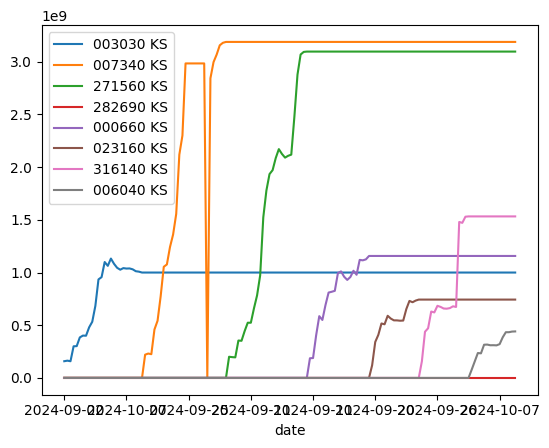

In [109]:
df.plot()

In [69]:
df.iloc[0]

date                     2024-09-02
num_shares: 003030 KS         900.0
num_shares: 007340 KS           0.0
num_shares: 271560 KS           0.0
num_shares: 282690 KS           0.0
num_shares: 000660 KS           0.0
num_shares: 023160 KS           0.0
num_shares: 316140 KS           0.0
num_shares: 006040 KS           0.0
Name: 0, dtype: object

In [46]:
df

,num_shares: 003030 KS,num_shares: 007340 KS,num_shares: 271560 KS,num_shares: 282690 KS,num_shares: 000660 KS,num_shares: 023160 KS,num_shares: 316140 KS,num_shares: 006040 KS,valuation: 003030 KS,valuation: 007340 KS,valuation: 271560 KS,valuation: 282690 KS,valuation: 000660 KS,valuation: 023160 KS,valuation: 316140 KS,valuation: 006040 KS
date,,,,,,,,,,,,,,,,
2024-09-02,900,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-05,1700,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-09,2200,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-10,2400,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-12,2750,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-23,5999,169245,31000,0,6000,52500,92500,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-24,5999,169245,31000,0,6000,52500,92500,7500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-26,5999,169245,31000,0,6000,52500,92500,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
df.reset_index().iloc[0]

date                     2024-09-02
num_shares: 003030 KS           900
num_shares: 007340 KS             0
num_shares: 271560 KS             0
num_shares: 282690 KS             0
num_shares: 000660 KS             0
num_shares: 023160 KS             0
num_shares: 316140 KS             0
num_shares: 006040 KS             0
Name: 0, dtype: object

In [45]:
get_price_of_date_by_ticker(ticker='003030 KS', date='2024-09-02')

176200

In [53]:
for col in df.columns:
    ticker = col.split(': ')[1]
    df[f'valuation: {ticker}'] = df.apply(lambda row: row[col] * get_price_of_date_by_ticker(ticker=ticker, date=row.name), axis=1)
df

,num_shares: 003030 KS,num_shares: 007340 KS,num_shares: 271560 KS,num_shares: 282690 KS,num_shares: 000660 KS,num_shares: 023160 KS,num_shares: 316140 KS,num_shares: 006040 KS,valuation: 003030 KS,valuation: 007340 KS,valuation: 271560 KS,valuation: 282690 KS,valuation: 000660 KS,valuation: 023160 KS,valuation: 316140 KS,valuation: 006040 KS
date,,,,,,,,,,,,,,,,
2024-09-02,900,0,0,0,0,0,0,0,158580000,0,0,0,0,0,0,0
2024-09-05,1700,0,0,0,0,0,0,0,300050000,0,0,0,0,0,0,0
2024-09-09,2200,0,0,0,0,0,0,0,384340000,0,0,0,0,0,0,0
2024-09-10,2400,0,0,0,0,0,0,0,401760000,0,0,0,0,0,0,0
2024-09-12,2750,0,0,0,0,0,0,0,480150000,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-23,5999,169245,31000,0,6000,52500,92500,5000,1093017800,17127594000,2901600000,0,972000000,767025000,1453175000,157500000
2024-09-24,5999,169245,31000,0,6000,52500,92500,7500,1147608700,17279914500,2855100000,0,981000000,774900000,1456875000,236250000
2024-09-26,5999,169245,31000,0,6000,52500,92500,10000,1132611200,17279914500,2966700000,0,1085400000,773850000,1489250000,315000000


In [9]:
def get_delta_shares_of_date(df, ticker, date):
    df_date = df[df['date'] == date]
    row = df_date[df_date['ticker'] == ticker]
    return row.iloc[0]['delta_shares']

In [10]:
get_delta_shares_of_date(df_nums, '003030 KS', '2024-09-02')

900

In [ ]:
df = self.pl.copy()[['date', 'ticker', 'num_shares', 'valuation']]
df['price_of_date'] = df.apply(lambda row: get_price_of_date_by_ticker(ticker=row['ticker'], date=row['date']), axis=1)
df['valuation_of_date'] = df['num_shares'] * df['price_of_date'] if df['type'] == 'Buy' else 0
df_valuation = df[['date', 'valuation_of_date', 'valuation']].groupby('date').sum()
df_valuation = df_valuation.rename(columns={'valuation': 'valuation_of_today'})


,date,ticker,delta_shares
49,2024-09-26,271560 KS,800
50,2024-09-26,316140 KS,2500
51,2024-09-26,006040 KS,2500
52,2024-09-26,000660 KS,500
53,2024-09-26,003030 KS,250
54,2024-10-07,282690 KS,-2500
55,2024-10-07,007340 KS,-29231
56,2024-10-08,271560 KS,3500
57,2024-10-08,007340 KS,148100
58,2024-10-08,007340 KS,8000


In [3]:
trades.history

,date,ticker,name,type,num_shares,price_average,net_amount,cash_flow
0,2024-09-02,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,900,177645.666667,160040981.0,-160040981.0
1,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,88110.280000,220495976.0,-220495976.0
2,2024-09-02,271560 KS,ORION CORP/REPUBLIC OF KOREA,Buy,2200,91495.772727,201491991.0,-201491991.0
3,2024-09-02,282690 KS,DONG AH TIRE & RUBBER CO LTD,Buy,2500,13007.988000,32552490.0,-32552490.0
4,2024-09-05,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,800,175209.750000,140307968.0,-140307968.0
...,...,...,...,...,...,...,...,...
64,2024-10-10,271560 KS,ORION CORP/REPUBLIC OF KOREA,Buy,3200,100062.375000,320519800.0,-320519800.0
65,2024-10-10,316140 KS,WOORI FINANCIAL GROUP INC,Buy,50000,16095.446200,805577082.0,-805577082.0
66,2024-10-10,007340 KS,DN AUTOMOTIVE CORP,Buy,8145,18878.147330,153916273.0,-153916273.0
67,2024-10-11,007340 KS,DN AUTOMOTIVE CORP,Buy,5000,18529.124000,92738266.0,-92738266.0


In [4]:
trades.pl_buys

,date,ticker,name,delta_shares,price_average,price_last,net_amount,evaluation,pl,return
0,2024-09-02,003030 KS,SEAH STEEL HOLDINGS CORP,900,177645.666667,166700.0,160040981.0,150030000.0,-10010981.0,-6.161516
1,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,2500,88110.280000,94200.0,220495976.0,235500000.0,15004024.0,6.911475
2,2024-09-02,271560 KS,ORION CORP/REPUBLIC OF KOREA,2200,91495.772727,99900.0,201491991.0,219780000.0,18288009.0,9.185372
3,2024-09-02,282690 KS,DONG AH TIRE & RUBBER CO LTD,2500,13007.988000,13500.0,32552490.0,33750000.0,1197510.0,3.782384
4,2024-09-05,003030 KS,SEAH STEEL HOLDINGS CORP,800,175209.750000,166700.0,140307968.0,133360000.0,-6947968.0,-4.856893
...,...,...,...,...,...,...,...,...,...,...
64,2024-10-10,271560 KS,ORION CORP/REPUBLIC OF KOREA,3200,100062.375000,99900.0,320519800.0,319680000.0,-839800.0,-0.162274
65,2024-10-10,316140 KS,WOORI FINANCIAL GROUP INC,50000,16095.446200,16570.0,805577082.0,828500000.0,22922918.0,2.948373
66,2024-10-10,007340 KS,DN AUTOMOTIVE CORP,8145,18878.147330,18840.0,153916273.0,153451800.0,-464473.0,-0.202071
67,2024-10-11,007340 KS,DN AUTOMOTIVE CORP,5000,18529.124000,18840.0,92738266.0,94200000.0,1461734.0,1.677770


In [5]:
trades.pl_sells

,date,ticker,name,delta_shares,average_purchase_price,price_last,realization,pl,return
54,2024-10-07,282690 KS,DONG AH TIRE & RUBBER CO LTD,-2500,13020.996000,13500.0,3.375000e+07,1197510.0,3.678705
55,2024-10-07,007340 KS,DN AUTOMOTIVE CORP,-29231,96359.942664,94200.0,2.753560e+09,-63137284.0,-2.241536


In [6]:
buys = trades.pl_buys
sells = trades.pl_sells

In [8]:
byus['date']

,date,ticker,name,delta_shares,average_purchase_price,price_last,realization,pl,return
54,2024-10-07,282690 KS,DONG AH TIRE & RUBBER CO LTD,-2500,13020.996000,13500.0,3.375000e+07,1197510.0,3.678705
55,2024-10-07,007340 KS,DN AUTOMOTIVE CORP,-29231,96359.942664,94200.0,2.753560e+09,-63137284.0,-2.241536


In [11]:
history = trades.history
history

,date,ticker,name,type,num_shares,price_average,net_amount,cash_flow
0,2024-09-02,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,900,177645.666667,160040981.0,-160040981.0
1,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,88110.280000,220495976.0,-220495976.0
2,2024-09-02,271560 KS,ORION CORP/REPUBLIC OF KOREA,Buy,2200,91495.772727,201491991.0,-201491991.0
3,2024-09-02,282690 KS,DONG AH TIRE & RUBBER CO LTD,Buy,2500,13007.988000,32552490.0,-32552490.0
4,2024-09-05,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,800,175209.750000,140307968.0,-140307968.0
...,...,...,...,...,...,...,...,...
64,2024-10-10,271560 KS,ORION CORP/REPUBLIC OF KOREA,Buy,3200,100062.375000,320519800.0,-320519800.0
65,2024-10-10,316140 KS,WOORI FINANCIAL GROUP INC,Buy,50000,16095.446200,805577082.0,-805577082.0
66,2024-10-10,007340 KS,DN AUTOMOTIVE CORP,Buy,8145,18878.147330,153916273.0,-153916273.0
67,2024-10-11,007340 KS,DN AUTOMOTIVE CORP,Buy,5000,18529.124000,92738266.0,-92738266.0


In [9]:
trades.get_pl_evaluated_of_buys()

,date,ticker,name,delta_shares,price_average,price_last,net_amount,evaluation,return
0,2024-09-02,003030 KS,SEAH STEEL HOLDINGS CORP,900,177645.666667,168100.0,160040981.0,151290000.0,-5.373431
1,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,2500,88110.280000,93950.0,220495976.0,234875000.0,6.627740
2,2024-09-02,271560 KS,ORION CORP/REPUBLIC OF KOREA,2200,91495.772727,99800.0,201491991.0,219560000.0,9.076078
3,2024-09-02,282690 KS,DONG AH TIRE & RUBBER CO LTD,2500,13007.988000,13500.0,32552490.0,33750000.0,3.782384
4,2024-09-05,003030 KS,SEAH STEEL HOLDINGS CORP,800,175209.750000,168100.0,140307968.0,134480000.0,-4.057851
...,...,...,...,...,...,...,...,...,...
64,2024-10-10,271560 KS,ORION CORP/REPUBLIC OF KOREA,3200,100062.375000,99800.0,320519800.0,319360000.0,-0.262211
65,2024-10-10,316140 KS,WOORI FINANCIAL GROUP INC,50000,16095.446200,16540.0,805577082.0,827000000.0,2.761985
66,2024-10-10,007340 KS,DN AUTOMOTIVE CORP,8145,18878.147330,18790.0,153916273.0,153044550.0,-0.466928
67,2024-10-11,007340 KS,DN AUTOMOTIVE CORP,5000,18529.124000,18790.0,92738266.0,93950000.0,1.407924


In [10]:
trades.get_pl_realized_of_sells()

,date,ticker,name,delta_shares,price_average,realization
54,2024-10-07,282690 KS,DONG AH TIRE & RUBBER CO LTD,-2500,13500.0,3.375000e+07
55,2024-10-07,007340 KS,DN AUTOMOTIVE CORP,-29231,102100.0,2.746252e+09


In [13]:
sells = trades.pl_sells
merged_info = trades.merged_info

In [14]:
sells

,date,ticker,name,delta_shares,price_average,realization
54,2024-10-07,282690 KS,DONG AH TIRE & RUBBER CO LTD,-2500,13500.0,3.375000e+07
55,2024-10-07,007340 KS,DN AUTOMOTIVE CORP,-29231,102100.0,2.746252e+09


In [17]:
df_dated = merged_info[merged_info['date']<sells.iloc[1]['date']]
df_named = df_dated[df_dated['name']==sells.iloc[1]['name']]
df_named

,date,name_x,ticker,type,num_shares,price_average,consideration,commission,net_amount,delta_shares,cash_flow,ticker_bbg,name_kr,name,market_index,sector,cap(/1e8),price_last
1,2024-09-02,DN AUTOMOTIVE,007340 KS,Buy,2500,88110.280000,220275700.0,220276.0,220495976.0,2500,-220495976.0,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0
5,2024-09-05,DN AUTOMOTIVE,007340 KS,Buy,2500,91637.240000,229093100.0,229093.0,229322193.0,2500,-229322193.0,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0
7,2024-09-06,DN AUTOMOTIVE,007340 KS,Buy,1000,90969.100000,90969100.0,90969.0,91060069.0,1000,-91060069.0,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0
10,2024-09-09,DN AUTOMOTIVE,007340 KS,Buy,2231,93556.611385,208724800.0,208725.0,208933525.0,2231,-208933525.0,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0
13,2024-09-10,DN AUTOMOTIVE,007340 KS,Buy,3500,90417.457143,316461100.0,316461.0,316777561.0,3500,-316777561.0,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0
16,2024-09-12,DN AUTOMOTIVE,007340 KS,Buy,1500,92685.933333,139028900.0,139029.0,139167929.0,1500,-139167929.0,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0
21,2024-09-13,DN AUTOMOTIVE,007340 KS,Buy,1500,92786.400000,139179600.0,139180.0,139318780.0,1500,-139318780.0,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0
24,2024-09-19,DN AUTOMOTIVE,007340 KS,Buy,1500,95794.600000,143691900.0,143692.0,143835592.0,1500,-143835592.0,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0
30,2024-09-20,DN AUTOMOTIVE,007340 KS,Buy,4500,102093.444444,459420500.0,459420.0,459879920.0,4500,-459879920.0,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0
39,2024-09-23,DN AUTOMOTIVE,007340 KS,Buy,2000,100705.900000,201411800.0,201412.0,201613212.0,2000,-201613212.0,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0


In [21]:
def get_average_purchase_price(df, date, name):
    df_dated = df[df['date']<date]
    df_named = df_dated[df_dated['name']==name]
    total_net_amount, total_num_shares = df_named['net_amount'].sum(), df_named['num_shares'].sum()
    average_purchase_price = total_net_amount/total_num_shares
    return average_purchase_price

In [20]:
df_named['net_amount'].sum(), df_named['num_shares'].sum()

(2816697484.0, 29231)

In [18]:
df_named['net_amount'].sum()/df_named['num_shares'].sum()

96359.94266361055

In [14]:
df = trades.merged_info.copy()
df = df[df['type'].isin(['Sell', 'Sell_synthetic'])]
def adjust_price(row):
    if row['ticker'] == '007340 KS' and row['date'] <= '2024-10-07':
        return row['price_last'] * 5
    return row['price_last']
# DN exceptions before '2024-10-07'
df['price_last'] = df.apply(adjust_price, axis=1)
df['realization'] = df['num_shares'] * df['price_last']
cols_to_keep = ['date', 'ticker', 'name', 'delta_shares', 'price_average', 'realization']
df = df[cols_to_keep]
df

,date,ticker,name,delta_shares,price_average,realization
54,2024-10-07,282690 KS,DONG AH TIRE & RUBBER CO LTD,-2500,13500.0,3.375000e+07
55,2024-10-07,007340 KS,DN AUTOMOTIVE CORP,-29231,102100.0,2.746252e+09


In [4]:
merged_info = trades.merged_info
merged_info_sell = merged_info[merged_info['type'].isin(['Sell', 'Sell_synthetic'])]
merged_info_sell

,date,name_x,ticker,type,num_shares,price_average,consideration,commission,net_amount,delta_shares,cash_flow,ticker_bbg,name_kr,name,market_index,sector,cap(/1e8),price_last
54,2024-10-07,DONG AH TIRE & RUBBER CO LTD,282690 KS,Sell_synthetic,2500,13500.0,3.375000e+07,0.0,3.375000e+07,-2500,3.375000e+07,282690 KS Equity,동아타이어,DONG AH TIRE & RUBBER CO LTD,KOSPI Index,Consumer Discretionary,1853.0,13500.0
55,2024-10-07,DN AUTOMOTIVE CORP,007340 KS,Sell_synthetic,29231,102100.0,2.984485e+09,0.0,2.984485e+09,-29231,2.984485e+09,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0


In [7]:
list(trades.history['date'])

['2024-09-02',
 '2024-09-02',
 '2024-09-02',
 '2024-09-02',
 '2024-09-05',
 '2024-09-05',
 '2024-09-05',
 '2024-09-06',
 '2024-09-09',
 '2024-09-09',
 '2024-09-09',
 '2024-09-10',
 '2024-09-10',
 '2024-09-10',
 '2024-09-10',
 '2024-09-12',
 '2024-09-12',
 '2024-09-12',
 '2024-09-12',
 '2024-09-13',
 '2024-09-13',
 '2024-09-13',
 '2024-09-13',
 '2024-09-19',
 '2024-09-19',
 '2024-09-19',
 '2024-09-19',
 '2024-09-19',
 '2024-09-20',
 '2024-09-20',
 '2024-09-20',
 '2024-09-20',
 '2024-09-20',
 '2024-09-20',
 '2024-09-20',
 '2024-09-23',
 '2024-09-23',
 '2024-09-23',
 '2024-09-23',
 '2024-09-23',
 '2024-09-23',
 '2024-09-23',
 '2024-09-24',
 '2024-09-24',
 '2024-09-24',
 '2024-09-24',
 '2024-09-24',
 '2024-09-24',
 '2024-09-26',
 '2024-09-26',
 '2024-09-26',
 '2024-09-26',
 '2024-09-26',
 '2024-09-26',
 '2024-10-07',
 '2024-10-07',
 '2024-10-08',
 '2024-10-08',
 '2024-10-08',
 '2024-10-08',
 '2024-10-08',
 '2024-10-10',
 '2024-10-10',
 '2024-10-10',
 '2024-10-10',
 '2024-10-10',
 '2024-10-

In [5]:
trades.get_merged_info(synthetic_trades=True)

| append synthetic trade of Sell (date) = (2024-10-07)
consideration: 2984485100
|- cash flow of synthetic trade: -2984485100.0
| append synthetic trade of Sell (date) = (2024-10-07)
consideration: 33750000
|- cash flow of synthetic trade: -33750000.0
| append synthetic trade of Buy (date) = (2024-10-08)
|- cash flow of synthetic trade: 2843520000.0


,date,name_x,ticker,type,num_shares,price_average,consideration,commission,net_amount,delta_shares,cash_flow,ticker_bbg,name_kr,name,market_index,sector,cap(/1e8),price_last
0,2024-09-02,SeAH Steel Holdings,003030 KS,Buy,900,177645.666667,1.598811e+08,159881.0,1.600410e+08,900,-1.600410e+08,003030 KS Equity,세아제강지주,SEAH STEEL HOLDINGS CORP,KOSPI Index,Materials,6962.0,168100.0
1,2024-09-02,DN AUTOMOTIVE,007340 KS,Buy,2500,88110.280000,2.202757e+08,220276.0,2.204960e+08,2500,-2.204960e+08,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0
2,2024-09-02,ORION,271560 KS,Buy,2200,91495.772727,2.012907e+08,201291.0,2.014920e+08,2200,-2.014920e+08,271560 KS Equity,오리온,ORION CORP/REPUBLIC OF KOREA,KOSPI Index,Consumer Staples,39457.0,99800.0
3,2024-09-02,DONG AH TIRE,282690 KS,Buy,2500,13007.988000,3.251997e+07,32520.0,3.255249e+07,2500,-3.255249e+07,282690 KS Equity,동아타이어,DONG AH TIRE & RUBBER CO LTD,KOSPI Index,Consumer Discretionary,1853.0,13500.0
4,2024-09-05,SeAH Steel Holdings,003030 KS,Buy,800,175209.750000,1.401678e+08,140168.0,1.403080e+08,800,-1.403080e+08,003030 KS Equity,세아제강지주,SEAH STEEL HOLDINGS CORP,KOSPI Index,Materials,6962.0,168100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,2024-10-11,DN AUTOMOTIVE,007340 KS,Buy,5000,18529.124000,9.264562e+07,92646.0,9.273827e+07,5000,-9.273827e+07,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0
65,2024-10-11,ORION,271560 KS,Buy,2500,99379.800000,2.484495e+08,248450.0,2.486980e+08,2500,-2.486980e+08,271560 KS Equity,오리온,ORION CORP/REPUBLIC OF KOREA,KOSPI Index,Consumer Staples,39457.0,99800.0
66,2024-10-07,DN AUTOMOTIVE CORP,007340 KS,Sell_synthetic,29231,102100.000000,2.984485e+09,0.0,2.984485e+09,-29231,-2.984485e+09,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0
67,2024-10-07,DONG AH TIRE & RUBBER CO LTD,282690 KS,Sell_synthetic,2500,13500.000000,3.375000e+07,0.0,3.375000e+07,-2500,-3.375000e+07,282690 KS Equity,동아타이어,DONG AH TIRE & RUBBER CO LTD,KOSPI Index,Consumer Discretionary,1853.0,13500.0


In [4]:
trades.history.tail(30)

,date,ticker,name,type,num_shares,price_average,net_amount,cash_flow
36,2024-09-23,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,250,184116.400000,46075129.0,-46075129.0
37,2024-09-23,006040 KS,DONGWON INDUSTRIES CO LTD,Buy,2500,31479.360000,78777098.0,-78777098.0
38,2024-09-23,007340 KS,DN AUTOMOTIVE CORP,Buy,2000,100705.900000,201613212.0,-201613212.0
39,2024-09-23,023160 KS,TK CORPORATION,Buy,4500,14670.400000,66082817.0,-66082817.0
40,2024-09-23,271560 KS,ORION CORP/REPUBLIC OF KOREA,Buy,2200,93522.636364,205955550.0,-205955550.0
41,2024-09-23,316140 KS,WOORI FINANCIAL GROUP INC,Buy,2000,15652.175000,31335654.0,-31335654.0
42,2024-09-24,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,500,189070.400000,94629735.0,-94629735.0
43,2024-09-24,006040 KS,DONGWON INDUSTRIES CO LTD,Buy,2500,31417.300000,78621793.0,-78621793.0
44,2024-09-24,007340 KS,DN AUTOMOTIVE CORP,Buy,6500,102404.169231,666292727.0,-666292727.0
45,2024-09-24,023160 KS,TK CORPORATION,Buy,7000,14643.414286,102606404.0,-102606404.0


AttributeError: 'Trades' object has no attribute 'history'

[{'date': '2024-10-07',
  'ticker': '007340 KS',
  'type': 'Sell',
  'num_share': 29231},
 {'date': '2024-10-07',
  'ticker': '282690 KS',
  'type': 'Sell',
  'num_share': 2500,
  'trades_history': None},
 {'date': '2024-10-08',
  'ticker': '007340 KS',
  'type': 'Buy',
  'num_share': 148100,
  'trades_history': None}]

In [3]:
SyntheticTrades(DNDONGA_MERGER).df

| append synthetic trade of Sell (date) = (2024-10-07)
consideration: 2984485100
|- cash flow of synthetic trade: -2984485100.0
| append synthetic trade of Sell (date) = (2024-10-07)
consideration: 33750000
|- cash flow of synthetic trade: -33750000.0
| append synthetic trade of Buy (date) = (2024-10-08)
|- cash flow of synthetic trade: 2843520000.0


,date,name,ticker,type,num_shares,average_price,consideration,commission,net_amount,delta_shares,cash_flow
0,2024-10-07,DN AUTOMOTIVE CORP,007340 KS,Sell_synthetic,29231,102100,2984485100,0.0,2.984485e+09,-29231,-2.984485e+09
1,2024-10-07,DONG AH TIRE & RUBBER CO LTD,282690 KS,Sell_synthetic,2500,13500,33750000,0.0,3.375000e+07,-2500,-3.375000e+07
2,2024-10-08,DN AUTOMOTIVE CORP,007340 KS,Buy_synthetic,148100,19200,2843520000,0.0,2.843520e+09,148100,2.843520e+09


NameError: name 'df_synthetic_dndong' is not defined

In [6]:
sell_dn = {
    'date': '2024-10-07',
    'ticker': '007340 KS',
    'type': 'Sell',
    'num_share': 29231,
}

sell_donga = {
    'date': '2024-10-07',
    'ticker': '282690 KS',
    'type': 'Sell',
    'num_share': 2500,
    'trades_history': None
}

buy_dn = {
    'date': '2024-10-08',
    'ticker': '007340 KS',
    'type': 'Buy',
    'num_share': 148100,
    'trades_history': None
}

In [7]:
trade_obj = SyntheticTrade(trade_data=buy_dn)
trade_obj.df

,date,name,ticker,type,num_shares,average_price,consideration,commission,net_amount,delta_shares,cash_flow
0,2024-10-08,DN AUTOMOTIVE CORP,007340 KS,Buy_synthetic,148100,19200,2843520000,0.0,2.843520e+09,148100,2.843520e+09


In [9]:
SyntheticTrade(trade_data=sell_dn).df
SyntheticTrade(trade_data=sell_donga).df

consideration: 2984485100
consideration: 33750000


,date,name,ticker,type,num_shares,average_price,consideration,commission,net_amount,delta_shares,cash_flow
0,2024-10-07,DONG AH TIRE & RUBBER CO LTD,282690 KS,Sell_synthetic,2500,13500,33750000,0.0,33750000.0,-2500,-33750000.0


NameError: name 'Trades' is not defined

In [3]:
trade_synthetic_dn = SyntheticTrade(date='2024-10-07', ticker='007340 KS', type='Sell', num_share=29231)
trade_synthetic_dn.get_df_synthetic_trade()

consideration: 2984485100


,date,name,ticker,type,num_shares,average_price,consideration,commission,net_amount,delta_shares,cash_flow
0,2024-10-07,DN AUTOMOTIVE CORP,007340 KS,Sell_synthetic,29231,102100,2984485100,0.0,2.984485e+09,-29231,-2.984485e+09


In [5]:
trade = Trade()

| import trade of (date, index) = (2024-10-11, -1)
|- cash flow of trade: -341436216.0


In [7]:
trade.df

,date,name,ticker,type,num_shares,average_price,consideration,commission,net_amount,delta_shares,cash_flow
0,2024-10-11,DN AUTOMOTIVE,007340 KS,Buy,5000,18529.124,92645620.0,92646,92738266.0,5000,-92738266.0
1,2024-10-11,ORION,271560 KS,Buy,2500,99379.800,248449500.0,248450,248697950.0,2500,-248697950.0


In [8]:
trade.df.columns

Index(['date', 'name', 'ticker', 'type', 'num_shares', 'average_price',
       'consideration', 'commission', 'net_amount', 'delta_shares',
       'cash_flow'],
      dtype='object')

In [2]:
trades = Trades()

| import trade of (date, index) = (2024-09-02, None)
|- cash flow of trade: -614581438.0
| import trade of (date, index) = (2024-09-05, None)
|- cash flow of trade: -529470241.0
| import trade of (date, index) = (2024-09-06, None)
|- cash flow of trade: -91060069.0
| import trade of (date, index) = (2024-09-09, None)
|- cash flow of trade: -384482599.0
| import trade of (date, index) = (2024-09-10, None)
|- cash flow of trade: -625076151.0
| import trade of (date, index) = (2024-09-12, None)
|- cash flow of trade: -528686258.0
| import trade of (date, index) = (2024-09-13, None)
|- cash flow of trade: -519691172.0
| import trade of (date, index) = (2024-09-19, None)
|- cash flow of trade: -727234488.0
| import trade of (date, index) = (2024-09-20, None)
|- cash flow of trade: -1931465216.0
| import trade of (date, index) = (2024-09-23, None)
|- cash flow of trade: -726876600.0
| import trade of (date, index) = (2024-09-24, None)
|- cash flow of trade: -1282227226.0
| import trade of (d

In [3]:
trades.get_merged_info()

,date,name_x,ticker,type,num_shares,price_average,consideration,commission,net_amount,delta_shares,cash_flow,ticker_bbg,name_kr,name,market_index,sector,cap(/1e8),price_last
0,2024-09-02,SeAH Steel Holdings,003030 KS,Buy,900,177645.666667,159881100.0,159881,160040981.0,900,-160040981.0,003030 KS Equity,세아제강지주,SEAH STEEL HOLDINGS CORP,KOSPI Index,Materials,6962.0,168100.0
1,2024-09-02,DN AUTOMOTIVE,007340 KS,Buy,2500,88110.280000,220275700.0,220276,220495976.0,2500,-220495976.0,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0
2,2024-09-02,ORION,271560 KS,Buy,2200,91495.772727,201290700.0,201291,201491991.0,2200,-201491991.0,271560 KS Equity,오리온,ORION CORP/REPUBLIC OF KOREA,KOSPI Index,Consumer Staples,39457.0,99800.0
3,2024-09-02,DONG AH TIRE,282690 KS,Buy,2500,13007.988000,32519970.0,32520,32552490.0,2500,-32552490.0,282690 KS Equity,동아타이어,DONG AH TIRE & RUBBER CO LTD,KOSPI Index,Consumer Discretionary,1853.0,13500.0
4,2024-09-05,SeAH Steel Holdings,003030 KS,Buy,800,175209.750000,140167800.0,140168,140307968.0,800,-140307968.0,003030 KS Equity,세아제강지주,SEAH STEEL HOLDINGS CORP,KOSPI Index,Materials,6962.0,168100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,2024-10-10,TKCORP.,023160 KS,Buy,4500,13919.971111,62639870.0,62640,62702510.0,4500,-62702510.0,023160 KS Equity,태광,TK CORPORATION,KOSDAQ Index,Industrials,3704.0,13980.0
62,2024-10-10,ORION,271560 KS,Buy,3200,100062.375000,320199600.0,320200,320519800.0,3200,-320519800.0,271560 KS Equity,오리온,ORION CORP/REPUBLIC OF KOREA,KOSPI Index,Consumer Staples,39457.0,99800.0
63,2024-10-10,WooriFinancialGroup,316140 KS,Buy,50000,16095.446200,804772310.0,804772,805577082.0,50000,-805577082.0,316140 KS Equity,우리금융지주,WOORI FINANCIAL GROUP INC,KOSPI Index,Financials,122824.0,16540.0
64,2024-10-11,DN AUTOMOTIVE,007340 KS,Buy,5000,18529.124000,92645620.0,92646,92738266.0,5000,-92738266.0,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0


In [4]:
trades.get_history()

,date,ticker,name,type,num_shares,price_average,net_amount,cash_flow
0,2024-09-02,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,900,177645.666667,160040981.0,-160040981.0
1,2024-09-02,007340 KS,DN AUTOMOTIVE CORP,Buy,2500,88110.280000,220495976.0,-220495976.0
2,2024-09-02,271560 KS,ORION CORP/REPUBLIC OF KOREA,Buy,2200,91495.772727,201491991.0,-201491991.0
3,2024-09-02,282690 KS,DONG AH TIRE & RUBBER CO LTD,Buy,2500,13007.988000,32552490.0,-32552490.0
4,2024-09-05,003030 KS,SEAH STEEL HOLDINGS CORP,Buy,800,175209.750000,140307968.0,-140307968.0
...,...,...,...,...,...,...,...,...
61,2024-10-10,023160 KS,TK CORPORATION,Buy,4500,13919.971111,62702510.0,-62702510.0
62,2024-10-10,271560 KS,ORION CORP/REPUBLIC OF KOREA,Buy,3200,100062.375000,320519800.0,-320519800.0
63,2024-10-10,316140 KS,WOORI FINANCIAL GROUP INC,Buy,50000,16095.446200,805577082.0,-805577082.0
64,2024-10-11,007340 KS,DN AUTOMOTIVE CORP,Buy,5000,18529.124000,92738266.0,-92738266.0


KeyError: "['price_lastnet_amount'] not in index"

In [6]:
trades.get_merged_info().columns

Index(['date', 'name_x', 'ticker', 'type', 'num_shares', 'average_price',
       'consideration', 'commission', 'net_amount', 'delta_shares',
       'cash_flow', 'ticker_bbg', 'name_kr', 'name_y', 'market_index',
       'sector', 'cap(/1e8)', 'price_last'],
      dtype='object')

In [5]:
trades.get_merged_info()

,date,name_x,ticker,type,num_shares,average_price,consideration,commission,net_amount,delta_shares,cash_flow,ticker_bbg,name_kr,name_y,market_index,sector,cap(/1e8),price_last
0,2024-09-02,SeAH Steel Holdings,003030 KS,Buy,900,177645.666667,159881100.0,159881,160040981.0,900,-160040981.0,003030 KS Equity,세아제강지주,SEAH STEEL HOLDINGS CORP,KOSPI Index,Materials,6962.0,168100.0
1,2024-09-02,DN AUTOMOTIVE,007340 KS,Buy,2500,88110.280000,220275700.0,220276,220495976.0,2500,-220495976.0,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0
2,2024-09-02,ORION,271560 KS,Buy,2200,91495.772727,201290700.0,201291,201491991.0,2200,-201491991.0,271560 KS Equity,오리온,ORION CORP/REPUBLIC OF KOREA,KOSPI Index,Consumer Staples,39457.0,99800.0
3,2024-09-02,DONG AH TIRE,282690 KS,Buy,2500,13007.988000,32519970.0,32520,32552490.0,2500,-32552490.0,282690 KS Equity,동아타이어,DONG AH TIRE & RUBBER CO LTD,KOSPI Index,Consumer Discretionary,1853.0,13500.0
4,2024-09-05,SeAH Steel Holdings,003030 KS,Buy,800,175209.750000,140167800.0,140168,140307968.0,800,-140307968.0,003030 KS Equity,세아제강지주,SEAH STEEL HOLDINGS CORP,KOSPI Index,Materials,6962.0,168100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,2024-10-10,TKCORP.,023160 KS,Buy,4500,13919.971111,62639870.0,62640,62702510.0,4500,-62702510.0,023160 KS Equity,태광,TK CORPORATION,KOSDAQ Index,Industrials,3704.0,13980.0
62,2024-10-10,ORION,271560 KS,Buy,3200,100062.375000,320199600.0,320200,320519800.0,3200,-320519800.0,271560 KS Equity,오리온,ORION CORP/REPUBLIC OF KOREA,KOSPI Index,Consumer Staples,39457.0,99800.0
63,2024-10-10,WooriFinancialGroup,316140 KS,Buy,50000,16095.446200,804772310.0,804772,805577082.0,50000,-805577082.0,316140 KS Equity,우리금융지주,WOORI FINANCIAL GROUP INC,KOSPI Index,Financials,122824.0,16540.0
64,2024-10-11,DN AUTOMOTIVE,007340 KS,Buy,5000,18529.124000,92645620.0,92646,92738266.0,5000,-92738266.0,007340 KS Equity,DN오토모티브,DN AUTOMOTIVE CORP,KOSPI Index,Consumer Discretionary,11380.0,18790.0


AttributeError: 'Trades' object has no attribute 'history'

In [2]:
trade = Trade()

- import trade of (date, index) = (2024-10-11, -1)
- cash flow of trade: -341436216.0


In [3]:
trade.df

,date,name,ticker,type,num_shares,average_price,consideration,commission,net_amount,delta_shares,cash_flow
0,2024-10-11,DN AUTOMOTIVE,007340 KS,Buy,5000,18529.124,92645620.0,92646,92738266.0,5000,-92738266.0
1,2024-10-11,ORION,271560 KS,Buy,2500,99379.800,248449500.0,248450,248697950.0,2500,-248697950.0


In [4]:
trade.data

[{'date': '2024-10-11',
  'ticker': '007340 KS',
  'type': 'Buy',
  'num_shares': 5000,
  'delta_shares': 5000},
 {'date': '2024-10-11',
  'ticker': '271560 KS',
  'type': 'Buy',
  'num_shares': 2500,
  'delta_shares': 2500}]

In [5]:
trade.df

,date,name,ticker,type,num_shares,average_price,consideration,commission,net_amount,delta_shares,cash_flow
0,2024-10-11,DN AUTOMOTIVE,007340 KS,Buy,5000,18529.124,92645620.0,92646,92738266.0,5000,-92738266.0
1,2024-10-11,ORION,271560 KS,Buy,2500,99379.800,248449500.0,248450,248697950.0,2500,-248697950.0


In [6]:
trade.timeseries

,"007340 KS: (2024-10-11, 5000)","271560 KS: (2024-10-11, 2500)",evaluation: 2024-10-11,cumreturn: 2024-10-11
date,,,,
2024-10-11,93250000,247500000,340750000,0.00000
2024-10-14,93950000,249500000,343450000,0.79237


- import trade of (date, index) = (2024-09-02, None)
- cash flow of trade: -614581438.0
- import trade of (date, index) = (2024-09-05, None)
- cash flow of trade: -529470241.0
- import trade of (date, index) = (2024-09-06, None)
- cash flow of trade: -91060069.0
- import trade of (date, index) = (2024-09-09, None)
- cash flow of trade: -384482599.0
- import trade of (date, index) = (2024-09-10, None)
- cash flow of trade: -625076151.0
- import trade of (date, index) = (2024-09-12, None)
- cash flow of trade: -528686258.0
- import trade of (date, index) = (2024-09-13, None)
- cash flow of trade: -519691172.0
- import trade of (date, index) = (2024-09-19, None)
- cash flow of trade: -727234488.0
- import trade of (date, index) = (2024-09-20, None)
- cash flow of trade: -1931465216.0
- import trade of (date, index) = (2024-09-23, None)
- cash flow of trade: -726876600.0
- import trade of (date, index) = (2024-09-24, None)
- cash flow of trade: -1282227226.0
- import trade of (date, index)

KeyError: 'cash_flow'

In [7]:
trades.history

,date,name,ticker,type,num_shares,average_price,consideration,commission,net_amount
0,2024-09-02,SeAH Steel Holdings,003030 KS,Buy,900,177645.666667,159881100.0,159881.0,160040981.0
1,2024-09-02,DN AUTOMOTIVE,007340 KS,Buy,2500,88110.280000,220275700.0,220276.0,220495976.0
2,2024-09-02,ORION,271560 KS,Buy,2200,91495.772727,201290700.0,201291.0,201491991.0
3,2024-09-02,DONG AH TIRE,282690 KS,Buy,2500,13007.988000,32519970.0,32520.0,32552490.0
4,2024-09-05,SeAH Steel Holdings,003030 KS,Buy,800,175209.750000,140167800.0,140168.0,140307968.0
...,...,...,...,...,...,...,...,...,...
64,2024-10-10,ORION,271560 KS,Buy,3200,100062.375000,320199600.0,320200.0,320519800.0
65,2024-10-10,WooriFinancialGroup,316140 KS,Buy,50000,16095.446200,804772310.0,804772.0,805577082.0
66,2024-10-10,DN AUTOMOTIVE,007340 KS,Buy,8145,18878.147330,153762510.0,153763.0,153916273.0
67,2024-10-11,DN AUTOMOTIVE,007340 KS,Buy,5000,18529.124000,92645620.0,92646.0,92738266.0
